# RETOCAR RETOCAR - Data Preprocessing and Supervised Learning


## 0. RETOCAR RETOCAR Contexto y enfoque

Este trabajo se apoyará en los notebooks de referencia `MIAX ML - 01 Data Preprocessing.ipynb` y `MIAX ML - 03 Linear Regression.ipynb`.

El dataset base serán `navs.pickle` y los factores Fama-French que se descargarán más adelante.  
Se prioriza simplicidad, claridad y justificación explícita de cada decisión metodológica.

> **Nota de reproducibilidad:** por motivos de tamaño, el archivo `navs.pickle` no se ha podido subir ni a GitHub ni al notebook.  
> Si se intenta re-ejecutar todo desde cero sin ese archivo, el pipeline no funcionará.  Es necesario añadirlo en local si se desea re-ejecutar.
> Aun así, el trabajo entregado queda correctamente ejecutado y documentado.

## 1. RETPCAR RETOCAR Objetivo y tesis financiera

**Hipótesis:** Asia tendrá buen comportamiento relativo, por lo que construiremos un fondo de fondos con sesgo Asia.

**Objetivo principal:** ......

**Restricciones de inversión:** cartera 70% Asia / 30% diversificación, cap 5% por fondo, filtros mínimos de calidad.



## 2. Carga y alineación temporal de datos

Esta sección no busca todavía "mejorar" los datos, sino **hacerlos comparables en el tiempo** y dejar un punto de partida reproducible para el resto del pipeline.  
La decisión central es separar claramente tres capas:

1. **Estructura** (qué objetos y columnas tenemos),
2. **Tiempo** (cómo representamos fechas y cronología),
3. **Persistencia** (qué versión del dato guardamos para reutilizar).

El motivo es metodológico: si se mezclan decisiones de limpieza avanzada (fase 4) con alineación temporal (fase 2), se pierde trazabilidad y luego es más difícil justificar por qué una métrica cambió.

Además, en un problema financiero, la consistencia temporal es crítica: antes de modelar hay que garantizar que las series están en un marco común y que no hay artefactos de indexado/duplicación.

---

Qué hace concretamente esta sección

- **Carga** de `navs.pickle` (NAVs de fondos) y de factores Fama-French (Asia ex Japan 3 Factors + MOM), guardando copias locales en CSV para reproducibilidad.
- **Parseo y estandarización** de fechas en un formato común para todo el pipeline.
- **Orden cronológico** y eliminación de duplicados.


#### 2.1 Configuración y librerías

La configuración se centraliza al inicio (`PICKLE_PATH`), carpetas de salida,  para evitar “constantes ocultas” dentro de celdas posteriores.  
La razón práctica es doble:

- **Reproducibilidad**: cambiar una ruta o parámetro en un único sitio.
- **Auditabilidad**: dejar explícitas las decisiones de diseño antes de ejecutar transformaciones.

También se importan librerías de descarga y parseo robusto (`requests`, `zipfile`, `io`) porque se decidió evitar dependencias frágiles en la obtención de factores `panda_datareader`.


In [4]:
import statsmodels.api as sm
import warnings
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pathlib import Path
import io
import zipfile
import requests
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# =========================
# Configuración
# =========================
PICKLE_PATH = Path("DOCS_CLASE") / "MachineLearning" / "dataset" / "navs.pickle"
OUTPUT_DIR = Path("data") / "daily_universe"
OUTPUT_PARQUET = OUTPUT_DIR / "panel_diario_universo.parquet"





#### 2.2 Carga y visualización inicial del `.pickle`

Aquí se valida primero la **estructura global del activo principal** (`navs_dict`) antes de transformar nada.  
La decisión de revisar `nº fondos`, `shape` agregado, columnas comunes y ejemplos concretos responde a una pregunta clave:  
**¿estamos tratando con un universo homogéneo o con múltiples excepciones estructurales?**

Se imprime una muestra de fondos para verificar que:
- el índice temporal existe,
- las columnas esperadas (`isin`, `allfunds_id`, `nav`, `name`) son consistentes,
- y el contenido es coherente con el contexto financiero.

Esto reduce riesgo de errores silenciosos en pasos posteriores (por ejemplo, asumir `date` como columna cuando viene en índice).


In [5]:
# 1) Cargar archivo
navs_dict = pd.read_pickle(PICKLE_PATH)

# Validación básica
if not isinstance(navs_dict, dict):
    raise TypeError(f"Se esperaba un dict y se recibió: {type(navs_dict)}")

print("Archivo cargado correctamente")
print(f"Tipo de objeto: {type(navs_dict).__name__}")
print(f"Cantidad de fondos: {len(navs_dict):,}")

# 2) Métricas globales: filas totales, columnas comunes y shape global lógico
n_fondos = len(navs_dict)
total_filas = 0
common_cols = None
shapes = []
non_df_funds = 0

for fund_id, df in navs_dict.items():
    if not isinstance(df, pd.DataFrame):
        non_df_funds += 1
        continue

    shapes.append(df.shape)
    total_filas += df.shape[0]

    cols = set(df.columns)
    if common_cols is None:
        common_cols = cols
    else:
        common_cols = common_cols.intersection(cols)

common_cols = sorted(common_cols) if common_cols is not None else []
shape_global = (total_filas, len(common_cols))  # shape lógico agregado

print(f"Shape global (agregado lógico): {shape_global}")
print(f"Columnas comunes ({len(common_cols)}): {common_cols}")
if non_df_funds > 0:
    print(f"Advertencia: {non_df_funds} fondos no son DataFrame")

# 3) Distribución rápida de shapes (top 5)
shape_counts = Counter(shapes)
print("\nTop 5 shapes más frecuentes:")
for shp, cnt in shape_counts.most_common(5):
    print(f"  {shp}: {cnt} fondos")

# 4) Mostrar algunos ejemplos de fondos
sample_ids = list(navs_dict.keys())[:3]
print(f"\nEjemplo de fondos (primeros {len(sample_ids)}):")
for fid in sample_ids:
    obj = navs_dict[fid]
    print(f"\n--- Fondo {fid} ---")
    if isinstance(obj, pd.DataFrame):
        print(f"shape: {obj.shape}")
        print(f"columnas: {obj.columns.tolist()}")
        display(obj.head(5))
    else:
        print(f"No es DataFrame. Tipo: {type(obj)}")

Archivo cargado correctamente
Tipo de objeto: dict
Cantidad de fondos: 24,822
Shape global (agregado lógico): (29455509, 4)
Columnas comunes (4): ['allfunds_id', 'isin', 'name', 'nav']

Top 5 shapes más frecuentes:
  (1387, 4): 977 fondos
  (1383, 4): 819 fondos
  (1384, 4): 695 fondos
  (1385, 4): 689 fondos
  (1425, 4): 576 fondos

Ejemplo de fondos (primeros 3):

--- Fondo 90 ---
shape: (1387, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0171310443,90,16.47,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-06,LU0171310443,90,16.19,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-07,LU0171310443,90,15.68,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-08,LU0171310443,90,15.59,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"
2016-01-11,LU0171310443,90,15.26,"BGF WORLD TECHNOLOGY ""A2"" (EUR)"



--- Fondo 541 ---
shape: (1373, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-01-05,LU0248272758,541,27.54,"BGF INDIA ""A2"""
2016-01-06,LU0248272758,541,27.50,"BGF INDIA ""A2"""
2016-01-07,LU0248272758,541,26.83,"BGF INDIA ""A2"""
2016-01-08,LU0248272758,541,27.21,"BGF INDIA ""A2"""
2016-01-11,LU0248272758,541,26.98,"BGF INDIA ""A2"""



--- Fondo 909 ---
shape: (1299, 4)
columnas: ['isin', 'allfunds_id', 'nav', 'name']


,isin,allfunds_id,nav,name
date,,,,
2016-05-11,LU1408527916,909,10.00,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-12,LU1408527916,909,10.03,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-13,LU1408527916,909,10.06,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-17,LU1408527916,909,10.07,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"
2016-05-18,LU1408527916,909,10.07,"BGF EMERGING MARKETS ""A"" (GBPHDG) D"


#### 2.3 Unificación diaria del universo en un único dataset

La decisión de transformar el diccionario de fondos en un **dataset largo diario** busca simplificar operaciones posteriores (merge temporal, controles de cobertura, joins con factores).  
Se convierte el índice a columna `date`, se estandarizan tipos y se resuelven duplicados por (`date`, `isin`) conservando la última observación, priorizando consistencia de clave temporal.

Se construye un panel diario completo `date x isin` para disponer de una matriz explícita de disponibilidad de NAV (observado vs faltante).  
Este enfoque favorece la transparencia de faltantes frente a enfoques donde los huecos quedan implícitos.

Guardar en `parquet` responde a una necesidad operativa: el CSV completo era muy pesado para trabajo y versionado.

Posibles críticas
- El producto cartesiano `date x isin` puede ser excesivo en memoria y disco.

Decisión de estructura: identificador único del fondo

Durante la construcción del dataset diario se detectó redundancia entre `fund_id` (clave del diccionario original) y `allfunds_id` (campo del propio dataset).  
En la práctica, ambas columnas representan el mismo identificador de fondo en las observaciones válidas.

Para reducir dimensionalidad y evitar duplicación semántica, se elimina `fund_id` y se conserva `allfunds_id` como identificador canónico, por ser el campo nativo del dato fuente y facilitar trazabilidad con el esquema original.

In [6]:
# Pipeline: navs_dict -> panel diario completo -> parquet
# Requiere navs_dict ya cargado en memoria

if "navs_dict" not in globals():
    raise ValueError("No existe `navs_dict` en memoria. Ejecuta primero la celda de carga.")

print("[1/6] Validando entrada...")
if not isinstance(navs_dict, dict):
    raise TypeError(f"`navs_dict` debe ser dict, recibido: {type(navs_dict)}")
print(f"    Fondos en diccionario: {len(navs_dict):,}")

print("[2/6] Aplanando a formato largo...")
rows = []

for fund_id, df in navs_dict.items():
    if not isinstance(df, pd.DataFrame):
        continue

    tmp = df.copy().reset_index()  # date está en índice
    tmp.columns = [str(c).strip().lower() for c in tmp.columns]

    # asegurar date
    if "date" not in tmp.columns:
        if "index" in tmp.columns:
            tmp = tmp.rename(columns={"index": "date"})
        else:
            tmp = tmp.rename(columns={tmp.columns[0]: "date"})

    # asegurar nav
    if "nav" not in tmp.columns:
        continue

    tmp["fund_id"] = fund_id
    # Evitamos duplicar IDs: conservamos allfunds_id como identificador canónico del fondo
    keep = ["date", "allfunds_id", "isin", "name", "nav"]
    keep = [c for c in keep if c in tmp.columns]
    tmp = tmp[keep]

    rows.append(tmp)

if not rows:
    raise RuntimeError("No se pudieron extraer fondos válidos con date/nav.")

daily_long_raw = pd.concat(rows, ignore_index=True)
print(f"    Filas concatenadas: {len(daily_long_raw):,}")

print("[3/6] Limpieza mínima de fecha y duplicados...")
daily_long_raw["date"] = pd.to_datetime(daily_long_raw["date"], errors="coerce", utc=True).dt.tz_localize(None)
daily_long_raw["nav"] = pd.to_numeric(daily_long_raw["nav"], errors="coerce")
daily_long_raw = daily_long_raw.dropna(subset=["date"]).copy()

if "isin" not in daily_long_raw.columns:
    raise RuntimeError("No existe columna 'isin'; no se puede construir panel por ISIN.")

daily_long_raw = (
    daily_long_raw
    .sort_values(["isin", "date"], kind="mergesort")
    .drop_duplicates(subset=["date", "isin"], keep="last")
    .reset_index(drop=True)
)

print("[4/6] Creando panel diario completo (date x isin)...")
global_min = daily_long_raw["date"].min()
global_max = daily_long_raw["date"].max()
all_days = pd.date_range(global_min, global_max, freq="D")
all_isins = daily_long_raw["isin"].dropna().drop_duplicates().sort_values()

calendar_df = pd.DataFrame({"date": all_days})
isins_df = pd.DataFrame({"isin": all_isins.values})
calendar_df["k"] = 1
isins_df["k"] = 1
daily_panel = calendar_df.merge(isins_df, on="k", how="inner").drop(columns="k")

obs = daily_long_raw[["date", "isin", "nav"]]
daily_panel = daily_panel.merge(obs, on=["date", "isin"], how="left")

meta_cols = [c for c in ["allfunds_id", "name"] if c in daily_long_raw.columns]
if meta_cols:
    meta_by_isin = (
        daily_long_raw
        .sort_values(["isin", "date"])
        .drop_duplicates(subset=["isin"], keep="last")[["isin"] + meta_cols]
    )
    daily_panel = daily_panel.merge(meta_by_isin, on="isin", how="left")

daily_panel = daily_panel.sort_values(["date", "isin"]).reset_index(drop=True)

print(f"    Rango global: {global_min.date()} -> {global_max.date()}")
print(f"    Filas panel: {len(daily_panel):,}")

print("[5/6] Guardando parquet...")
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PARQUET = OUT_DIR / "panel_diario_universo.parquet"
if OUT_PARQUET.exists():
    OUT_PARQUET.unlink()

daily_panel.to_parquet(OUT_PARQUET, index=False)

print(f"    Parquet guardado en: {OUT_PARQUET.as_posix()}")

print("[6/6] Vista previa")
display(daily_panel.head(10))

[1/6] Validando entrada...
    Fondos en diccionario: 24,822
[2/6] Aplanando a formato largo...
    Filas concatenadas: 29,455,509
[3/6] Limpieza mínima de fecha y duplicados...
[4/6] Creando panel diario completo (date x isin)...
    Rango global: 2016-01-05 -> 2021-07-16
    Filas panel: 50,134,380
[5/6] Guardando parquet...
    Parquet guardado en: data/daily_universe/panel_diario_universo.parquet
[6/6] Vista previa


,date,isin,nav,allfunds_id,name
0,2016-01-05,AT0000494893,297.13,60265,"ERSTE STOCK ISTANBUL ""VT"" (EUR)"
1,2016-01-05,AT0000495304,142.24,21156,"RAIFFEISEN TOP DIVIDEND EQ ""R-VTA"" ACC"
2,2016-01-05,AT0000497268,215.88,21157,"RAIFFEISEN EMERGING M ""R"" (EUR) A"
3,2016-01-05,AT0000607270,177.58,817028,"RAIFFEISEN 304 EURO COR ""I-VTA"" ACC"
4,2016-01-05,AT0000673165,484.11,60256,"ERSTE STOCK BIOTEC ""VTA"" (EUR)"
5,2016-01-05,AT0000673181,74.41,60271,"ERSTE STOCK EUROPE EMERGING ""VT"" (EUR)"
6,2016-01-05,AT0000673199,172.47,60268,"ERSTE BOND DANUBIA ""VT"" EUR"
7,2016-01-05,AT0000673306,181.43,173258,"ERSTE BOND EM GOVERNMENT ""VT"" (EUR)"
8,2016-01-05,AT0000704333,234.64,60264,"ERSTE STOCK ISTANBUL ""A"" (EUR) D"
9,2016-01-05,AT0000712534,190.69,817008,"RAIFFEISEN EURO CORPO ""R"" (EUR) A"


#### 2.4 Carga de factores Fama-French (Asia ex Japan)

Se decide descargar factores directamente desde los ZIP oficiales de Ken French en lugar de depender de `pandas_datareader`. El motivo principal es de **robustez y mantenimiento**: evitar warnings deprecados internos y reducir dependencia de implementaciones intermedias que pueden cambiar.

La normalización posterior (`date` a `datetime`, orden, deduplicación, conversión numérica) busca dejar factores listos para cruce temporal con NAVs sin ambigüedades de parseo.

Guardar una copia local en `data/factors` responde a reproducibilidad: una vez descargado, el pipeline no depende de red en cada ejecución.


In [4]:
# =========================================================
# Descarga directa desde Ken French (ZIP) + guardado en CSV
# =========================================================

print("[1/7] Configurando carpeta de salida...")
FACTORS_DIR = Path("data") / "factors"
FACTORS_DIR.mkdir(parents=True, exist_ok=True)
print(f"    Carpeta: {FACTORS_DIR.as_posix()}")

print("[2/7] Definiendo función de descarga/parseo robusta...")

def load_ken_french_daily_zip(url: str) -> pd.DataFrame:
    # Descargar ZIP
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    # Leer archivo interno txt/csv
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        inner_files = [n for n in zf.namelist() if n.lower().endswith((".txt", ".csv"))]
        if not inner_files:
            raise RuntimeError(f"No se encontró TXT/CSV dentro del ZIP: {url}")
        inner_name = inner_files[0]
        lines = zf.read(inner_name).decode("latin1", errors="ignore").splitlines()

    # Buscar inicio de tabla diaria: primera línea con fecha YYYYMMDD
    start_data = None
    for i, line in enumerate(lines):
        s = line.strip()
        if len(s) >= 8 and s[:8].isdigit():
            # normalmente el header está justo arriba
            start_data = max(i - 1, 0)
            break
    if start_data is None:
        raise RuntimeError(f"No se encontró bloque de datos en: {url}")

    # Cortar bloque útil (hasta notas/metadatos del final)
    block = []
    for line in lines[start_data:]:
        s = line.strip()
        if s == "":
            # después de arrancar y tener varias líneas, vacío suele marcar fin de bloque
            if len(block) > 5:
                break
            continue
        block.append(line)

    if len(block) < 2:
        raise RuntimeError(f"Bloque de datos insuficiente en: {url}")

    # Parsear tabla
    df = pd.read_csv(io.StringIO("\n".join(block)))

    # Normalizar columna fecha
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "date"})
    df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")

    # Limpieza mínima estructural
    df = (
        df.dropna(subset=["date"])
          .sort_values("date")
          .drop_duplicates(subset=["date"], keep="last")
          .reset_index(drop=True)
    )

    # Convertir factores a numérico
    for c in df.columns:
        if c != "date":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


print("[3/7] Descargando factores Asia ex Japan desde Ken French...")
URL_3F = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_3_Factors_Daily_CSV.zip"
URL_MOM = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Asia_Pacific_ex_Japan_MOM_Factor_Daily_CSV.zip"

ff_asia = load_ken_french_daily_zip(URL_3F)
mom_asia = load_ken_french_daily_zip(URL_MOM)

print("[4/7] Control de estructura descargada...")
print(f"    FF filas: {len(ff_asia):,} | columnas: {ff_asia.columns.tolist()}")
print(f"    MOM filas: {len(mom_asia):,} | columnas: {mom_asia.columns.tolist()}")
print(f"    FF rango: {ff_asia['date'].min().date()} -> {ff_asia['date'].max().date()}")
print(f"    MOM rango: {mom_asia['date'].min().date()} -> {mom_asia['date'].max().date()}")

print("[5/7] Guardando CSV locales (reemplazo si existen)...")
FF_CSV = FACTORS_DIR / "ff_asia_pacific_3factors_daily.csv"
MOM_CSV = FACTORS_DIR / "mom_asia_pacific_daily.csv"

if FF_CSV.exists():
    FF_CSV.unlink()
if MOM_CSV.exists():
    MOM_CSV.unlink()

ff_asia.to_csv(FF_CSV, index=False, encoding="utf-8")
mom_asia.to_csv(MOM_CSV, index=False, encoding="utf-8")

print(f"    Guardado: {FF_CSV.as_posix()}")
print(f"    Guardado: {MOM_CSV.as_posix()}")

print("[6/7] Preview")
display(ff_asia.head(5))
display(mom_asia.head(5))

print("[7/7] Factores listos para cruce temporal con NAVs.")

[1/7] Configurando carpeta de salida...
    Carpeta: data/factors
[2/7] Definiendo función de descarga/parseo robusta...
[3/7] Descargando factores Asia ex Japan desde Ken French...
[4/7] Control de estructura descargada...
    FF filas: 9,305 | columnas: ['date', 'Mkt-RF', 'SMB', 'HML', 'RF']
    MOM filas: 9,217 | columnas: ['date', 'WML']
    FF rango: 1990-07-02 -> 2026-02-27
    MOM rango: 1990-11-01 -> 2026-02-27
[5/7] Guardando CSV locales (reemplazo si existen)...
    Guardado: data/factors/ff_asia_pacific_3factors_daily.csv
    Guardado: data/factors/mom_asia_pacific_daily.csv
[6/7] Preview


,date,Mkt-RF,SMB,HML,RF
0,1990-07-02,0.40,-0.09,0.60,0.03
1,1990-07-03,0.86,-0.64,0.30,0.03
2,1990-07-04,1.28,-0.29,-0.30,0.03
3,1990-07-05,0.20,-0.57,-0.34,0.03
4,1990-07-06,-0.07,-0.16,0.42,0.03


,date,WML
0,1990-11-01,0.72
1,1990-11-02,0.96
2,1990-11-05,-1.41
3,1990-11-06,-0.13
4,1990-11-07,0.01


[7/7] Factores listos para cruce temporal con NAVs.


#### 2.5 Unificación de factores en un único dataset

Unificar `Mkt-RF`, `SMB`, `HML`, `RF` con `WML` en una sola tabla reduce complejidad en etapas de modelado y evita joins repetidos.  
La decisión de usar `inner join` por `date` es deliberada: solo se conservan fechas donde todos los factores relevantes existen, garantizando una base consistente para features.

Esto implica que el inicio temporal queda determinado por el factor con menor historial (`WML`), lo cual en este caso es aceptable porque no se requiere explotar periodos anteriores para el análisis actual, podria recortarse incluso hasta la fecha de inicio del archivo navs.pickle.

El resultado (`factores_unificados.csv`) actúa como fuente canónica de factores para el resto del notebook.


In [5]:
#Unificación de factores (3 factores + momentum WML)

print("[1/6] Cargando CSV de factores...")
FACTORS_DIR = Path("data") / "factors"
ff_path = FACTORS_DIR / "ff_asia_pacific_3factors_daily.csv"
mom_path = FACTORS_DIR / "mom_asia_pacific_daily.csv"

ff = pd.read_csv(ff_path)
mom = pd.read_csv(mom_path)

print(f"    FF shape : {ff.shape}")
print(f"    MOM shape: {mom.shape}")

print("[2/6] Normalizando fechas y tipos...")
ff["date"] = pd.to_datetime(ff["date"], errors="coerce")
mom["date"] = pd.to_datetime(mom["date"], errors="coerce")

ff = ff.dropna(subset=["date"]).copy()
mom = mom.dropna(subset=["date"]).copy()

# Asegurar numérico en factores
for c in ["Mkt-RF", "SMB", "HML", "RF"]:
    if c in ff.columns:
        ff[c] = pd.to_numeric(ff[c], errors="coerce")

if "WML" in mom.columns:
    mom["WML"] = pd.to_numeric(mom["WML"], errors="coerce")
else:
    raise RuntimeError("No se encontró la columna 'WML' en mom_asia_pacific_daily.csv")

print("[3/6] Ordenando y quitando duplicados por fecha...")
ff = ff.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)
mom = mom.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

print("[4/6] Uniendo datasets por fecha...")
# inner join => solo fechas comunes (arranca cuando existe WML)
factores_unificados = ff.merge(mom[["date", "WML"]], on="date", how="inner")
factores_unificados = factores_unificados.sort_values("date").reset_index(drop=True)

print("[5/6] Control de resultado...")
print(f"    Shape unificado: {factores_unificados.shape}")
print(f"    Columnas: {factores_unificados.columns.tolist()}")
print(f"    Rango: {factores_unificados['date'].min().date()} -> {factores_unificados['date'].max().date()}")

print("[6/6] Guardando CSV final...")
out_path = FACTORS_DIR / "factores_unificados.csv"
if out_path.exists():
    out_path.unlink()

factores_unificados.to_csv(out_path, index=False, encoding="utf-8")
print(f"    Guardado en: {out_path.as_posix()}")

display(factores_unificados.head(10))

[1/6] Cargando CSV de factores...
    FF shape : (9305, 5)
    MOM shape: (9217, 2)
[2/6] Normalizando fechas y tipos...
[3/6] Ordenando y quitando duplicados por fecha...
[4/6] Uniendo datasets por fecha...
[5/6] Control de resultado...
    Shape unificado: (9217, 6)
    Columnas: ['date', 'Mkt-RF', 'SMB', 'HML', 'RF', 'WML']
    Rango: 1990-11-01 -> 2026-02-27
[6/6] Guardando CSV final...
    Guardado en: data/factors/factores_unificados.csv


,date,Mkt-RF,SMB,HML,RF,WML
0,1990-11-01,-1.38,0.97,0.07,0.03,0.72
1,1990-11-02,-1.03,-0.05,-0.26,0.03,0.96
2,1990-11-05,1.20,-0.67,0.26,0.03,-1.41
3,1990-11-06,0.40,0.01,-0.30,0.03,-0.13
4,1990-11-07,-0.22,-0.51,-0.43,0.03,0.01
5,1990-11-08,-0.14,-0.32,1.05,0.03,0.03
6,1990-11-09,-0.56,0.70,-0.15,0.03,0.67
7,1990-11-12,0.44,-0.52,0.00,0.03,0.60
8,1990-11-13,0.87,-1.32,-0.19,0.03,0.42
9,1990-11-14,-0.29,-0.46,0.46,0.03,1.19


## 3. EDA (exploración de calidad)

En esta sección se revisa la calidad de los datos de forma **solo diagnóstica**: tamaños, tipos, nulos y comportamientos básicos. El objetivo es detectar problemas antes de limpiar y modelar, sin aplicar correcciones ni imputaciones.

Se trabaja sobre `daily_panel` (y factores cuando proceda) y se cubre:
- **Vista general** (3.1): shape, tipos, nulos globales, consistencia de metadatos.
- **Cobertura temporal** (3.2): completitud por fondo, heterogeneidad de historial.
- **Frecuencia de actualización** (3.3): distinción entre NaN por frecuencia natural vs. falta de datos.
- **Calidad de NAV** (3.4): valores no plausibles (≤0), saltos extremos, anomalías preliminares.
- **Sistema de alertas** (3.5): umbrales por fondo para priorizar la fase de limpieza.

---

**Decisiones a justificar (y cómo se justifican en este notebook)**

| Decisión | Valor adoptado | Justificación |
|----------|----------------|---------------|
| **Indicadores de calidad prioritarios** | Shape, tipos, nulos globales; cobertura por fondo (ratio_completitud, obs_nav_no_nulo); frecuencia observada; calidad de NAV (≤0, extremos); flags consolidados | Se priorizan porque definen qué fondos son aptos para modelado y qué problemas hay que resolver antes. La cobertura por fondo evita mezclar fondos con historial suficiente con otros casi vacíos. La frecuencia distingue NaN estructural (semanal/mensual) de mala calidad. |
| **Gráficos mínimos** | Barras de nulos por columna (3.1); barras de distribución de frecuencia (3.3); histogramas y umbrales de extremos para retornos (3.4); tablas Top 50 menor/mayor cobertura (3.2) | Las barras de nulos detectan columnas problemáticas de forma rápida. La distribución de frecuencia explica gran parte de los NaN. Los histogramas de retornos revelan outliers. Las tablas de cobertura orientan el filtrado en la fase 4. |
| **Umbrales preliminares para alertas** | `cobertura_baja < 0.60`; `historial < 252` obs; `nav_null_alto > 0.50` | **0.60**: ratio de completitud bajo indica muchos huecos; umbral estándar conservador. **252**: ~1 año de días laborables; mínimo razonable para series temporales. **0.50**: más de la mitad de NAV nulos implica señal muy incompleta. Estos umbrales son **preliminares** y se revisan en la fase 4. |

---

**Entregable de la sección:** resumen de calidad con tablas y gráficos básicos de diagnóstico, y sistema de alertas que sirva de puente a la fase 4.

### 3.1 - Vista general de calidad del dataset

Diagnóstico inicial de calidad sobre `daily_panel` para validar estructura, cobertura e integridad antes de la fase de limpieza.

**Qué hace esta subsección:**
- Shape (filas × columnas) y número de fondos por `allfunds_id` e `isin`.
- Rango temporal global (fecha mínima y máxima).
- Porcentaje global de `nav` nulo. 
- Listado de columnas disponibles.
- Controles de consistencia de metadatos: ausencia de múltiples ISIN por `allfunds_id`, múltiples IDs por ISIN, múltiples nombres por identificador.
- Gráfico de barras de % de nulos en variables clave (`nav`, `allfunds_id`, `isin`, `name`, `date`).

**Posibles críticas**
- El % global de nulos puede ser engañoso en panel diario (muchos NaN son estructurales por frecuencia de publicación).
- La consistencia de metadatos no detecta errores más sutiles (p. ej. cambios de nombre en el tiempo).

In [3]:
# Diagnóstico inicial: sin limpieza correctiva ni transformación de frecuencia.


if "daily_panel" not in globals():
    raise NameError(
        "No existe `daily_panel` en memoria. Ejecuta antes la fase de construccion/carga del panel diario."
    )

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

# Referencia directa para evitar copiar un dataset potencialmente grande.
df = daily_panel


def detect_date_col(dataframe: pd.DataFrame):
    preferred = ["date", "nav_date", "fecha", "datetime", "timestamp"]
    cols_lower = {c.lower(): c for c in dataframe.columns}

    for candidate in preferred:
        if candidate in cols_lower:
            return cols_lower[candidate]

    dt_cols = dataframe.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    return dt_cols[0] if dt_cols else None


def safe_nunique(dataframe: pd.DataFrame, col: str):
    if col not in dataframe.columns:
        return np.nan
    return dataframe[col].nunique(dropna=True)


# 1) Shape y columnas
n_rows, n_cols = df.shape
column_list = df.columns.tolist()

# 2) Numero de fondos
n_funds_allfunds = safe_nunique(df, "allfunds_id")
n_funds_isin = safe_nunique(df, "isin")

# 3) Rango temporal global
date_col = detect_date_col(df)
if date_col is not None:
    date_series = pd.to_datetime(df[date_col], errors="coerce")
    date_min = date_series.min()
    date_max = date_series.max()
else:
    date_min, date_max = pd.NaT, pd.NaT

# 4) NAV nulo global
nav_null_pct = (df["nav"].isna().mean() * 100) if "nav" in df.columns else np.nan

# 5) Consistencia basica de metadatos
issues = {
    "allfunds_id_con_multiples_isin": np.nan,
    "isin_con_multiples_allfunds_id": np.nan,
    "allfunds_id_con_multiples_name": np.nan,
    "isin_con_multiples_name": np.nan,
}

if {"allfunds_id", "isin"}.issubset(df.columns):
    id_to_isin = df.dropna(subset=["allfunds_id"]).groupby("allfunds_id")["isin"].nunique(dropna=True)
    isin_to_id = df.dropna(subset=["isin"]).groupby("isin")["allfunds_id"].nunique(dropna=True)
    issues["allfunds_id_con_multiples_isin"] = int((id_to_isin > 1).sum())
    issues["isin_con_multiples_allfunds_id"] = int((isin_to_id > 1).sum())

if {"allfunds_id", "name"}.issubset(df.columns):
    id_to_name = df.dropna(subset=["allfunds_id"]).groupby("allfunds_id")["name"].nunique(dropna=True)
    issues["allfunds_id_con_multiples_name"] = int((id_to_name > 1).sum())

if {"isin", "name"}.issubset(df.columns):
    isin_to_name = df.dropna(subset=["isin"]).groupby("isin")["name"].nunique(dropna=True)
    issues["isin_con_multiples_name"] = int((isin_to_name > 1).sum())

# 6) Tabla resumen para reporte
summary_31 = pd.DataFrame(
    {
        "metrica": [
            "n_filas",
            "n_columnas",
            "n_fondos_por_allfunds_id",
            "n_fondos_por_isin",
            "fecha_min_global",
            "fecha_max_global",
            "porcentaje_nav_nulo",
            "allfunds_id_con_multiples_isin",
            "isin_con_multiples_allfunds_id",
            "allfunds_id_con_multiples_name",
            "isin_con_multiples_name",
        ],
        "valor": [
            n_rows,
            n_cols,
            n_funds_allfunds,
            n_funds_isin,
            date_min,
            date_max,
            nav_null_pct,
            issues["allfunds_id_con_multiples_isin"],
            issues["isin_con_multiples_allfunds_id"],
            issues["allfunds_id_con_multiples_name"],
            issues["isin_con_multiples_name"],
        ],
    }
)

print("=" * 88)
print("SECCION 3.1 - VISTA GENERAL DE CALIDAD (DIAGNOSTICO INICIAL)")
print("=" * 88)
print(f"Shape: {n_rows:,} filas x {n_cols:,} columnas")
print(f"N fondos por allfunds_id: {n_funds_allfunds if not pd.isna(n_funds_allfunds) else 'N/A'}")
print(f"N fondos por isin: {n_funds_isin if not pd.isna(n_funds_isin) else 'N/A'}")
print(f"Rango temporal global ({date_col if date_col else 'sin columna fecha'}): {date_min} -> {date_max}")
if pd.isna(nav_null_pct):
    print("% global de nav nulo: N/A (columna 'nav' no disponible)")
else:
    print(f"% global de nav nulo: {nav_null_pct:.2f}%")
print("-" * 88)
print("Columnas disponibles:")
print(column_list)
print("-" * 88)
print("Consistencia basica de metadatos:")
for k, v in issues.items():
    print(f"  - {k}: {v}")
print("=" * 88)

display(summary_31)

# Visual simple de nulos en columnas clave
key_cols = [c for c in ["nav", "allfunds_id", "isin", "name", date_col] if c is not None and c in df.columns]
if key_cols:
    nulls_key = (df[key_cols].isna().mean() * 100).sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=nulls_key.index, y=nulls_key.values, hue=nulls_key.index, palette="Blues_d", legend=False)
    ax.set_title("% de nulos en variables clave")
    ax.set_xlabel("Variable")
    ax.set_ylabel("% nulos")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas clave disponibles para graficar nulos.")

NameError: No existe `daily_panel` en memoria. Ejecuta antes la fase de construccion/carga del panel diario.

Interpretación de consistencia básica de metadatos (3.1)

| Métrica | Significado | Si = 0 |
|---------|-------------|--------|
| `allfunds_id_con_multiples_isin` | Fondos que tienen más de un ISIN asociado | Cada fondo tiene un solo ISIN |
| `isin_con_multiples_allfunds_id` | ISIN que apuntan a más de un fondo | Cada ISIN corresponde a un solo fondo |
| `allfunds_id_con_multiples_name` | Fondos con más de un nombre distinto | Cada fondo tiene un solo nombre |
| `isin_con_multiples_name` | ISIN con más de un nombre | Cada ISIN tiene un solo nombre |

**Decisiones que permite:**

- `allfunds_id` e `isin` son claves válidas para joins y agrupaciones.
- No hay ambigüedad entre identificadores.
- Se puede usar cualquier identificador como clave principal para metadatos.
- En la fase 4 se puede agrupar por fondo sin riesgo de mezclar registros distintos.


### 3.2 - Cobertura temporal y completitud por fondo

En datasets financieros de panel, mirar solo métricas globales puede ocultar un riesgo clave: **heterogeneidad de historial entre fondos**. Dos fondos pueden convivir en el mismo dataset, pero uno tener una serie casi completa y otro estar severamente incompleto.

Por eso, en esta subsección diagnosticamos cobertura **a nivel fondo** (clave real para modelado), midiendo:

- `min_date` y `max_date` para delimitar ventana observada por fondo.
- observaciones con `nav` no nulo para cuantificar señal utilizable.
- días calendario entre `min_date` y `max_date` para estimar densidad temporal.
- ratio de completitud (`obs_no_nulo / dias_calendario`) para comparar fondos en escala homogénea.
- flag de mínimo historial de 1 año (>= 252 observaciones con NAV) como criterio preliminar de elegibilidad.

Por qué al menos 1 año de historial

| Razón | Explicación |
|-------|-------------|
| **Estimación de retornos** | Con muy pocas observaciones, los retornos calculados son muy ruidosos. Un año da suficiente serie para estimar volatilidad y tendencia con más estabilidad. |
| **Features y ventanas temporales** | Medias móviles, volatilidad reciente u otros indicadores suelen usar ventanas de varias semanas o meses. Con menos de 1 año no tienes margen razonable para calcular esas features. |
| **Cobertura de estacionalidad** | Un año cubre ciclos estacionales (trimestres, semestres). Fondos con menos de 1 año no permiten evaluar un comportamiento medio/largo plazo. |
| **Modelado supervisado** | Para clasificación o regresión hace falta suficiente variación en la variable objetivo. Con muy pocas observaciones hay riesgo alto de sobreajuste y resultados poco fiables. |


Este diagnóstico **no corrige ni excluye**. Su objetivo es preparar decisiones de fase 4 (limpieza) y fase 5 (feature engineering) con evidencia cuantitativa, evitando sesgos por fondos con historial insuficiente.

In [7]:
# 3.2 - Cobertura temporal y completitud por fondo (diagnostico)
# Restricciones: sin imputar, sin borrar fondos, solo diagnostico EDA.

if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# Clave de fondo prioritaria
if "allfunds_id" in panel.columns:
    fund_col = "allfunds_id"
elif "isin" in panel.columns:
    fund_col = "isin"
else:
    raise KeyError("Se requiere `allfunds_id` o `isin` para calcular cobertura por fondo.")

# Columna temporal
if "date" in panel.columns:
    date_col = "date"
else:
    dt_candidates = panel.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt_candidates:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    date_col = dt_candidates[0]

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para medir completitud por fondo.")

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

coverage_by_fund = (
    work.groupby(fund_col, dropna=False)
        .agg(
            min_date=(date_col, "min"),
            max_date=(date_col, "max"),
            obs_nav_no_nulo=("nav", lambda s: int(s.notna().sum())),
        )
        .reset_index()
)

coverage_by_fund["dias_calendario"] = (
    (coverage_by_fund["max_date"] - coverage_by_fund["min_date"]).dt.days + 1
).clip(lower=1)

coverage_by_fund["ratio_completitud"] = (
    coverage_by_fund["obs_nav_no_nulo"] / coverage_by_fund["dias_calendario"]
)

coverage_by_fund["flag_historial_min_1y"] = (
    coverage_by_fund["obs_nav_no_nulo"] >= 252
).astype(int)

# Tablas solicitadas
top_50_menor_cobertura = coverage_by_fund.sort_values(
    ["ratio_completitud", "obs_nav_no_nulo", "dias_calendario"],
    ascending=[True, True, False]
).head(50)

top_50_mayor_cobertura = coverage_by_fund.sort_values(
    ["ratio_completitud", "obs_nav_no_nulo", "dias_calendario"],
    ascending=[False, False, False]
).head(50)

# Resumen global de regla minima 1 anio (>=252 obs NAV)
resumen_min_historial = (
    coverage_by_fund["flag_historial_min_1y"]
    .value_counts(dropna=False)
    .rename_axis("flag_historial_min_1y")
    .reset_index(name="n_fondos")
    .sort_values("flag_historial_min_1y", ascending=False)
)
resumen_min_historial["porcentaje"] = (
    resumen_min_historial["n_fondos"] / resumen_min_historial["n_fondos"].sum() * 100
)

n_fondos_total = coverage_by_fund[fund_col].nunique(dropna=True)
n_fondos_ok = int((coverage_by_fund["flag_historial_min_1y"] == 1).sum())
n_fondos_no = int((coverage_by_fund["flag_historial_min_1y"] == 0).sum())

print("=" * 92)
print("SECCION 3.2 - COBERTURA TEMPORAL Y COMPLETITUD POR FONDO")
print("=" * 92)
print(f"Clave de fondo usada: {fund_col}")
print(f"Fondos evaluados: {n_fondos_total:,}")
print(f"Fondos con historial >= 252 obs NAV: {n_fondos_ok:,}")
print(f"Fondos con historial < 252 obs NAV: {n_fondos_no:,}")
print("-" * 92)
print("Top 50 fondos con MENOR cobertura (ratio_completitud)")
display(top_50_menor_cobertura)
print("Top 50 fondos con MAYOR cobertura (ratio_completitud)")
display(top_50_mayor_cobertura)
print("Resumen global de minimo historial (1 = cumple, 0 = no cumple)")
display(resumen_min_historial)

# Objeto util para pipeline en siguientes fases
coverage_32 = coverage_by_fund.copy()

SECCION 3.2 - COBERTURA TEMPORAL Y COMPLETITUD POR FONDO
Clave de fondo usada: allfunds_id
Fondos evaluados: 24,819
Fondos con historial >= 252 obs NAV: 24,228
Fondos con historial < 252 obs NAV: 591
--------------------------------------------------------------------------------------------
Top 50 fondos con MENOR cobertura (ratio_completitud)


,allfunds_id,min_date,max_date,obs_nav_no_nulo,dias_calendario,ratio_completitud,flag_historial_min_1y
261,1636,2016-01-05,2021-07-16,1,2020,0.000495,0
263,1642,2016-01-05,2021-07-16,1,2020,0.000495,0
265,1645,2016-01-05,2021-07-16,1,2020,0.000495,0
625,4813,2016-01-05,2021-07-16,1,2020,0.000495,0
671,4910,2016-01-05,2021-07-16,1,2020,0.000495,0
678,4924,2016-01-05,2021-07-16,1,2020,0.000495,0
682,4928,2016-01-05,2021-07-16,1,2020,0.000495,0
686,4932,2016-01-05,2021-07-16,1,2020,0.000495,0
797,6083,2016-01-05,2021-07-16,1,2020,0.000495,0
1116,7795,2016-01-05,2021-07-16,1,2020,0.000495,0


Top 50 fondos con MAYOR cobertura (ratio_completitud)


,allfunds_id,min_date,max_date,obs_nav_no_nulo,dias_calendario,ratio_completitud,flag_historial_min_1y
16024,187743,2016-01-05,2021-07-16,2016,2020,0.998020,1
17760,215070,2016-01-05,2021-07-16,2016,2020,0.998020,1
8020,70019,2016-01-05,2021-07-16,2015,2020,0.997525,1
15557,175855,2016-01-05,2021-07-16,2015,2020,0.997525,1
18065,220250,2016-01-05,2021-07-16,2015,2020,0.997525,1
21968,273625,2016-01-05,2021-07-16,2015,2020,0.997525,1
24612,567026,2016-01-05,2021-07-16,2015,2020,0.997525,1
24613,567070,2016-01-05,2021-07-16,2015,2020,0.997525,1
24616,590030,2016-01-05,2021-07-16,2015,2020,0.997525,1
8670,76297,2016-01-05,2021-07-16,2014,2020,0.997030,1


Resumen global de minimo historial (1 = cumple, 0 = no cumple)


,flag_historial_min_1y,n_fondos,porcentaje
0,1,24228,97.61876
1,0,591,2.38124


Distribucion de fondos con historial < 252

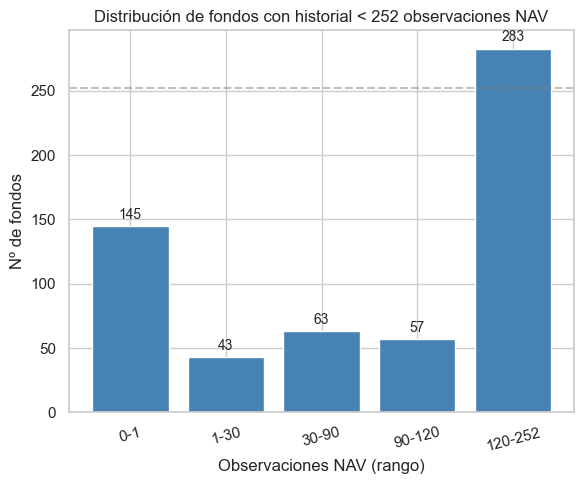

Resumen por rango de observaciones:
bucket
0-1        145
1-30        43
30-90       63
90-120      57
120-252    283

Total fondos < 252 obs: 591


In [8]:
# Fondos con historial < 252
fondos_lt_252 = coverage_by_fund[coverage_by_fund["obs_nav_no_nulo"] < 252].copy()

# Límites de los intervalos (en obs NAV)
limites = [0, 1, 30, 90, 120, 252]
etiquetas = ["0-1", "1-30", "30-90", "90-120", "120-252"]

fondos_lt_252["bucket"] = pd.cut(
    fondos_lt_252["obs_nav_no_nulo"],
    bins=limites,
    labels=etiquetas,
    include_lowest=True,
)

distribucion = fondos_lt_252["bucket"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(distribucion.index.astype(str), distribucion.values, color="steelblue", edgecolor="white")

ax.set_xlabel("Observaciones NAV (rango)")
ax.set_ylabel("Nº de fondos")
ax.set_title("Distribución de fondos con historial < 252 observaciones NAV")
ax.axhline(y=252, color="gray", linestyle="--", alpha=0.5, label="Umbral 252")
plt.xticks(rotation=15)

# Valores sobre cada barra
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{int(h)}", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Resumen numérico
print("Resumen por rango de observaciones:")
print(distribucion.to_string())
print(f"\nTotal fondos < 252 obs: {fondos_lt_252.shape[0]}")

**Interpretación (3.2)**

- **Esperado sano**: la mayoría de fondos cumple el umbral mínimo de historial. Concretamente, **24.228 fondos** tienen ≥252 observaciones NAV (`flag_historial_min_1y = 1`), frente a **591 fondos** por debajo. La distribución de los 591 con historial insuficiente muestra que **145 fondos (24,5%)** tienen 0–1 observaciones, **86 (14,6%)** entre 1–30, y **283 (47,9%)** entre 120–252 (cercanos al umbral).

- **Señal de riesgo**: existe una cola de fondos con baja completitud o historial muy corto. Los **188 fondos** con menos de 30 observaciones pueden introducir ruido y sesgo en modelos supervisados. Los **145 fondos con 0–1 obs** son especialmente problemáticos (casi sin historial). El gráfico de distribución por rangos (0–1, 1–30, 30–90, 90–120, 120–252) refleja esta heterogeneidad y prioriza dónde concentrar el filtrado en fase 4.

- **Diferencia entre cobertura y longitud**: un fondo puede tener `min_date` antigua pero baja completitud (muchos huecos), por lo que antigüedad no equivale a calidad de historial. Los indicadores `ratio_completitud` y `obs_nav_no_nulo` capturan esto: un fondo con muchos días entre min y max pero pocas obs tendrá ratio bajo y `flag_historial_min_1y = 0`.

- **Implicación para fase 4**: este diagnóstico define umbrales de exclusión o reglas de tratamiento. Se recomienda excluir al menos los fondos con <30 obs NAV (188 fondos); los 283 entre 120–252 pueden evaluarse según el modelo (ya que podrian tener frecuencia semanal). El sistema de alertas de 3.5 usa estos umbrales para priorizar el trabajo de limpieza.

### 3.3 - Frecuencia observada de actualización NAV por fondo

En un panel diario de fondos, la presencia de `NaN` en `nav` no siempre implica mala calidad de dato. Muchas veces refleja la **frecuencia natural de publicación** del fondo (por ejemplo, semanal o mensual).  

Por eso, antes de limpiar o imputar, conviene inferir la frecuencia observada a partir de fechas válidas por fondo.

Este diagnóstico permite separar dos fenómenos distintos:

- **NaN estructural**: esperado por diseño de publicación (fondos no diarios).
- **NaN potencialmente problemático**: huecos anómalos para la frecuencia esperada del fondo.

La clasificación en `daily`, `weekly`, `monthly`, `irregular` (más `insufficient_data`) no corrige nada todavía, pero aporta evidencia para justificar en fases posteriores una posible homogenización temporal (por ejemplo, frecuencia semanal) con menor riesgo de distorsión.

SECCION 3.3 - FRECUENCIA OBSERVADA DE ACTUALIZACION NAV POR FONDO
Heuristica usada:
- insufficient_data: < 8 observaciones validas de NAV
- daily: mediana gap <= 2 y >= 80% gaps <= 3
- weekly: mediana gap [5,9] y >= 60% gaps en [4,10]
- monthly: mediana gap [24,35] y >= 50% gaps en [20,40]
- irregular: resto
--------------------------------------------------------------------------------------------
Distribucion de fondos por categoria de frecuencia observada


,freq_categoria,n_fondos,porcentaje
0,daily,24438,98.464886
1,insufficient_data,162,0.652726
2,irregular,136,0.547967
3,weekly,78,0.314275
4,monthly,5,0.020146


Ejemplos de fondos por categoria (hasta 5 por categoria)


,allfunds_id,freq_categoria,n_obs_nav_validas,median_gap_dias,p90_gap_dias,min_date,max_date
0,187743,daily,2016,1.0,1.0,2016-01-05,2021-07-15
1,215070,daily,2016,1.0,1.0,2016-01-05,2021-07-15
2,70019,daily,2015,1.0,1.0,2016-01-05,2021-07-15
3,175855,daily,2015,1.0,1.0,2016-01-05,2021-07-14
4,220250,daily,2015,1.0,1.0,2016-01-05,2021-07-15
5,54669,insufficient_data,7,132.5,369.5,2018-05-31,2021-04-30
6,175693,insufficient_data,7,1.0,2.0,2017-06-27,2017-07-05
7,255398,insufficient_data,7,1.0,176.0,2020-07-24,2021-07-15
8,295598,insufficient_data,6,1.0,2.2,2021-07-08,2021-07-15
9,317726,insufficient_data,6,1.0,2.2,2021-07-08,2021-07-15


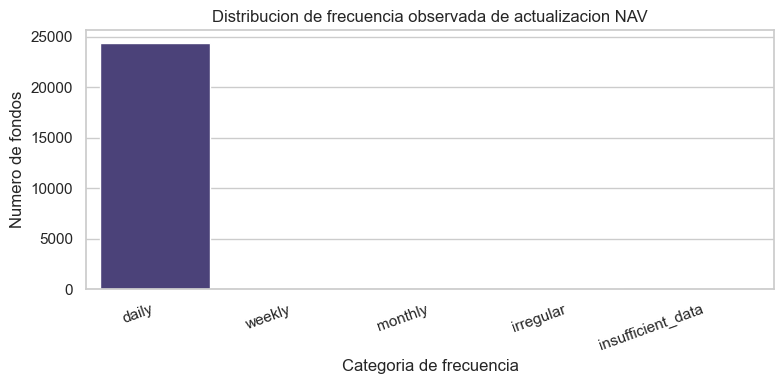

In [9]:
# 3.3 - Frecuencia observada de actualizacion NAV por fondo (solo caracterizacion)
# Restricciones: no remuestrear, no imputar, no limpiar correctivamente.

if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# Seleccion robusta de clave de fondo
if "allfunds_id" in panel.columns:
    fund_col = "allfunds_id"
elif "isin" in panel.columns:
    fund_col = "isin"
else:
    raise KeyError("Se requiere `allfunds_id` o `isin` para analizar frecuencia por fondo.")

# Seleccion robusta de fecha
if "date" in panel.columns:
    date_col = "date"
else:
    dt_candidates = panel.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt_candidates:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    date_col = dt_candidates[0]

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para inferir frecuencia observada.")

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# Solo fechas con NAV valido
valid_nav = work.loc[work["nav"].notna(), [fund_col, date_col]].copy()
valid_nav = valid_nav.sort_values([fund_col, date_col]).drop_duplicates([fund_col, date_col])


def classify_frequency(gaps_days: pd.Series, min_obs_required: int = 8) -> str:
    """
    Heuristica explicita basada en gaps entre fechas con NAV no nulo:
    - insufficient_data: menos de `min_obs_required` observaciones validas.
    - daily: mediana gap <= 2 dias y >=80% gaps <= 3 dias.
    - weekly: mediana gap entre 5 y 9 dias y >=60% gaps entre 4 y 10 dias.
    - monthly: mediana gap entre 24 y 35 dias y >=50% gaps entre 20 y 40 dias.
    - irregular: resto de casos.
    """
    n_obs = len(gaps_days) + 1
    if n_obs < min_obs_required:
        return "insufficient_data"

    med = float(gaps_days.median())
    p_daily_like = float((gaps_days <= 3).mean()) if len(gaps_days) else 0.0
    p_weekly_like = float(gaps_days.between(4, 10, inclusive="both").mean()) if len(gaps_days) else 0.0
    p_monthly_like = float(gaps_days.between(20, 40, inclusive="both").mean()) if len(gaps_days) else 0.0

    if med <= 2 and p_daily_like >= 0.80:
        return "daily"
    if 5 <= med <= 9 and p_weekly_like >= 0.60:
        return "weekly"
    if 24 <= med <= 35 and p_monthly_like >= 0.50:
        return "monthly"
    return "irregular"


# Calculo de estadisticas de gap por fondo
rows = []
for fund_id, g in valid_nav.groupby(fund_col):
    dates = g[date_col].sort_values()
    gaps = dates.diff().dropna().dt.days
    n_obs = int(len(dates))

    if n_obs <= 1:
        freq_cat = "insufficient_data"
        median_gap = np.nan
        p90_gap = np.nan
    else:
        freq_cat = classify_frequency(gaps)
        median_gap = float(gaps.median())
        p90_gap = float(gaps.quantile(0.90))

    rows.append(
        {
            fund_col: fund_id,
            "n_obs_nav_validas": n_obs,
            "min_date": dates.min() if n_obs else pd.NaT,
            "max_date": dates.max() if n_obs else pd.NaT,
            "median_gap_dias": median_gap,
            "p90_gap_dias": p90_gap,
            "freq_categoria": freq_cat,
        }
    )

freq_by_fund = pd.DataFrame(rows)

# Distribucion por categoria
dist_freq = (
    freq_by_fund["freq_categoria"]
    .value_counts(dropna=False)
    .rename_axis("freq_categoria")
    .reset_index(name="n_fondos")
)
dist_freq["porcentaje"] = dist_freq["n_fondos"] / dist_freq["n_fondos"].sum() * 100

# Ejemplos por categoria (hasta 5 fondos por categoria)
examples_by_category = (
    freq_by_fund
    .sort_values(["freq_categoria", "n_obs_nav_validas"], ascending=[True, False])
    .groupby("freq_categoria", as_index=False)
    .head(5)
    [[fund_col, "freq_categoria", "n_obs_nav_validas", "median_gap_dias", "p90_gap_dias", "min_date", "max_date"]]
    .reset_index(drop=True)
)

print("=" * 92)
print("SECCION 3.3 - FRECUENCIA OBSERVADA DE ACTUALIZACION NAV POR FONDO")
print("=" * 92)
print("Heuristica usada:")
print("- insufficient_data: < 8 observaciones validas de NAV")
print("- daily: mediana gap <= 2 y >= 80% gaps <= 3")
print("- weekly: mediana gap [5,9] y >= 60% gaps en [4,10]")
print("- monthly: mediana gap [24,35] y >= 50% gaps en [20,40]")
print("- irregular: resto")
print("-" * 92)
print("Distribucion de fondos por categoria de frecuencia observada")
display(dist_freq)
print("Ejemplos de fondos por categoria (hasta 5 por categoria)")
display(examples_by_category)

# Grafico simple
plot_order = ["daily", "weekly", "monthly", "irregular", "insufficient_data"]
plot_df = dist_freq.copy()
plot_df["freq_categoria"] = pd.Categorical(plot_df["freq_categoria"], categories=plot_order, ordered=True)
plot_df = plot_df.sort_values("freq_categoria")

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=plot_df, x="freq_categoria", y="n_fondos", hue="freq_categoria", palette="viridis", legend=False)
ax.set_title("Distribucion de frecuencia observada de actualizacion NAV")
ax.set_xlabel("Categoria de frecuencia")
ax.set_ylabel("Numero de fondos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Objeto util para pipeline posterior
freq_33 = freq_by_fund.copy()

**Interpretación de resultados (3.3)**

- **Dominancia de fondos daily (~98.5%)**: Casi todos los fondos se clasifican como actualización diaria; los NaN no se deben en su mayoría a fondos semanales o mensuales. La alta proporción de nulos global (sección 3.4) responde más a inicio/fin de series, festivos o huecos puntuales que a diseño de publicación.
- **weekly (78) y monthly (5)**: Muy minoritarios; la homogenización a frecuencia semanal tendría impacto limitado en el conjunto del universo.
- **insufficient_data (162)**: Fondos con pocas observaciones válidas; conviene excluirlos o tratarlos aparte en modelado para evitar inferencia poco fiable.
- **irregular (136)**: Patrones de actualización no claramente daily/weekly/monthly; candidatos a revisión manual o reglas específicas en la fase de limpieza.
- **Conclusión**: El panel es principalmente diario por diseño observado; el análisis a frecuencia diaria es razonable. Una homogenización a semanal sería opcional para reducir ruido, no necesaria por tener muchos fondos no diarios.

### 3.4 - Calidad de NAV y anomalías preliminares

Antes de limpiar o modelar, conviene auditar la calidad de `nav` porque esta variable es la base de retornos, features y etiquetas posteriores. Si `nav` contiene huecos, valores no plausibles (`<= 0`) o saltos extremos, el riesgo es propagar ruido a toda la cadena analítica.

En esta subsección diferenciamos **diagnóstico** de **corrección**:

- Medimos nulos globales y por fondo,
- Identificamos casos `nav <= 0`,
- Evaluamos la distribución de NAV,
- Analizamos retornos diarios (agregados) y marcamos extremos con percentiles e IQR globales, sin limpieza correctiva,
- Marcamos extremos con criterios explícitos (percentiles 1%-99% e IQR).

Esto permite anticipar si los problemas son puntuales o sistémicos y preparar reglas de fase 4 con evidencia, evitando decisiones ad hoc.

SECCION 3.4 - CALIDAD DE NAV Y ANOMALIAS PRELIMINARES
Filas evaluadas: 50,134,380
% NAV nulo global: 41.25%
NAV <= 0 global: 0 (0.00%)
Retornos validos analizados: 22,953,912
Umbral extremos percentiles (1%-99%): [-0.025459, 0.023269]
Umbral extremos IQR: [-0.008837, 0.009730]
----------------------------------------------------------------------------------------------
Estadisticos de retornos diarios POR FONDO (muestra: fondos con mas retornos validos)


,allfunds_id,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_ret_valid
16024,187743,2013.0,0.000054,0.000992,-0.013127,-0.002458,-0.001045,-0.000126,0.000052,0.000312,0.001147,0.002634,0.006262,2013
17760,215070,2013.0,0.000064,0.001174,-0.014894,-0.002990,-0.001102,-0.000117,0.000051,0.000331,0.001214,0.003217,0.009855,2013
15557,175855,2012.0,0.000009,0.000976,-0.008762,-0.003062,-0.001253,-0.000187,0.000040,0.000187,0.001245,0.002727,0.012690,2012
24613,567070,2012.0,-0.000005,0.000603,-0.012830,-0.001442,-0.000546,-0.000096,0.000027,0.000095,0.000536,0.001229,0.004802,2012
24612,567026,2012.0,0.000340,0.009828,-0.113623,-0.030241,-0.013229,-0.001577,-0.000054,0.003473,0.013085,0.024370,0.096893,2012
24616,590030,2012.0,0.000148,0.007954,-0.104513,-0.022400,-0.011827,-0.001746,-0.000059,0.003020,0.011395,0.020664,0.040840,2012
9349,82293,2011.0,-0.000020,0.000053,-0.000640,-0.000196,-0.000111,-0.000031,-0.000021,0.000007,0.000047,0.000085,0.000673,2011
8671,76298,2011.0,0.000062,0.002639,-0.034681,-0.007851,-0.002955,-0.000367,0.000013,0.000722,0.003078,0.007204,0.022076,2011
24536,542016,2011.0,0.000090,0.008697,-0.113660,-0.025235,-0.012617,-0.001848,-0.000024,0.002969,0.012294,0.023328,0.076924,2011
18065,220250,2011.0,0.000073,0.001708,-0.025936,-0.004505,-0.001657,-0.000107,0.000072,0.000407,0.001729,0.004326,0.015047,2011


Top 50 fondos por incidencia de anomalias (score combinado diagnostico)


,allfunds_id,n_rows,n_nav_null,n_nav_nonpos,pct_nav_null,pct_nav_nonpos,n_ret_valid,n_extremos_pct,n_extremos_iqr,pct_extremos_pct,pct_extremos_iqr,anom_score
8920,79184,2020,1973,0,0.976733,0.0,36,10,24,0.277778,0.666667,0.608523
23619,291534,2020,1920,0,0.950495,0.0,77,17,47,0.220779,0.610390,0.576829
22244,276575,2020,1842,0,0.911881,0.0,132,22,81,0.166667,0.613636,0.564613
22249,276671,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22250,276689,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22247,276641,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
22248,276646,2020,1842,0,0.911881,0.0,132,26,80,0.196970,0.606061,0.561583
20023,250317,2020,1704,0,0.843564,0.0,244,59,160,0.241803,0.655738,0.557543
15054,167213,2020,1797,0,0.889604,0.0,220,88,133,0.400000,0.604545,0.553180
15412,172939,2020,2005,0,0.992574,0.0,10,1,5,0.100000,0.500000,0.547401


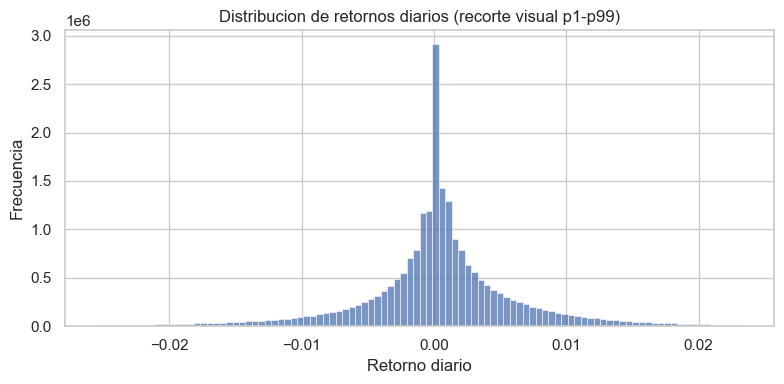

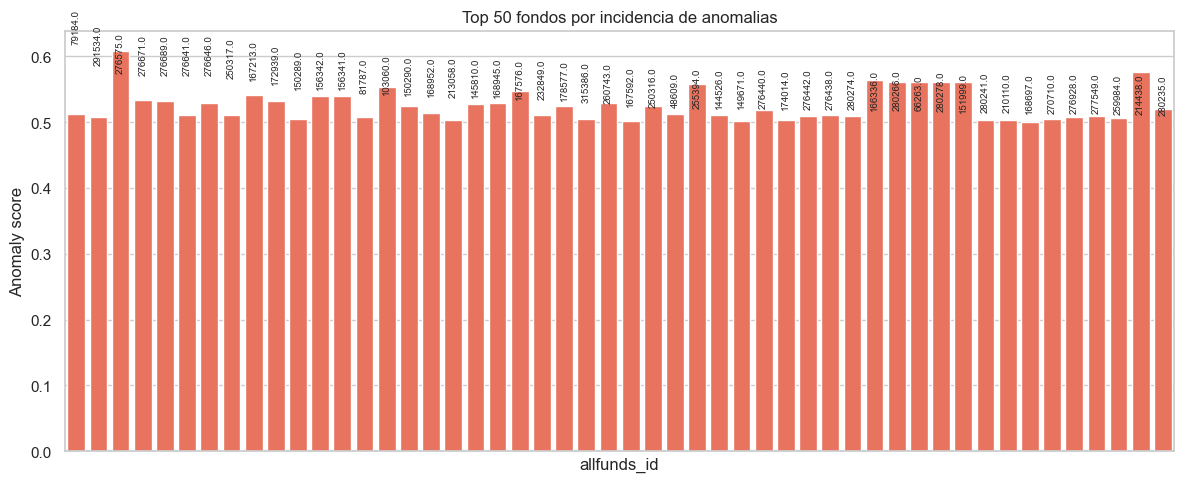

In [10]:
# 3.4 - Calidad de NAV y anomalías preliminares (EDA diagnóstico)
# Restricciones: no corregir, no imputar, no eliminar registros.
# Sin estadísticos de NAV; con estadísticos de retornos diarios por fondo.

if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

if "nav" not in panel.columns:
    raise KeyError("Se requiere columna `nav` para el diagnostico 3.4.")

def _pick_fund_col(df: pd.DataFrame) -> str:
    if "allfunds_id" in df.columns:
        return "allfunds_id"
    if "isin" in df.columns:
        return "isin"
    raise KeyError("Se requiere `allfunds_id` o `isin` para analisis por fondo.")

def _pick_date_col(df: pd.DataFrame) -> str:
    if "date" in df.columns:
        return "date"
    dt = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    return dt[0]

fund_col = _pick_fund_col(panel)
date_col = _pick_date_col(panel)

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# 1) Nulos NAV global y por fondo
n_total = len(work)
nav_null_global_pct = float(work["nav"].isna().mean() * 100)

nav_quality_by_fund = (
    work.groupby(fund_col)
    .agg(
        n_rows=("nav", "size"),
        n_nav_null=("nav", lambda s: int(s.isna().sum())),
        n_nav_nonpos=("nav", lambda s: int((s <= 0).sum())),
    )
    .reset_index()
)
nav_quality_by_fund["pct_nav_null"] = nav_quality_by_fund["n_nav_null"] / nav_quality_by_fund["n_rows"]
nav_quality_by_fund["pct_nav_nonpos"] = nav_quality_by_fund["n_nav_nonpos"] / nav_quality_by_fund["n_rows"]

# 2) Casos nav <= 0 global
n_nav_nonpos_global = int((work["nav"] <= 0).sum())
pct_nav_nonpos_global = float((work["nav"] <= 0).mean() * 100)

# 3) Retornos diarios por fondo (sin limpieza correctiva)
ret_df = work[[fund_col, date_col, "nav"]].copy().sort_values([fund_col, date_col])
ret_df["ret_1d"] = ret_df.groupby(fund_col)["nav"].pct_change(fill_method=None)
ret_df["ret_1d"] = ret_df["ret_1d"].replace([np.inf, -np.inf], np.nan)

ret_series = ret_df["ret_1d"].dropna()

# 4) Estadísticos de retornos diarios POR FONDO
ret_stats_by_fund = (
    ret_df.groupby(fund_col)["ret_1d"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)

# 5) Extremos diagnósticos (criterio explícito)
q_low, q_high = ret_series.quantile([0.01, 0.99]) if len(ret_series) else (np.nan, np.nan)
ret_df["flag_extremo_pct"] = ret_df["ret_1d"].lt(q_low) | ret_df["ret_1d"].gt(q_high)

q1, q3 = ret_series.quantile([0.25, 0.75]) if len(ret_series) else (np.nan, np.nan)
iqr = q3 - q1 if pd.notna(q1) and pd.notna(q3) else np.nan
iqr_low = q1 - 1.5 * iqr if pd.notna(iqr) else np.nan
iqr_high = q3 + 1.5 * iqr if pd.notna(iqr) else np.nan
ret_df["flag_extremo_iqr"] = ret_df["ret_1d"].lt(iqr_low) | ret_df["ret_1d"].gt(iqr_high)

ret_anom_by_fund = (
    ret_df.groupby(fund_col)
    .agg(
        n_ret_valid=("ret_1d", lambda s: int(s.notna().sum())),
        n_extremos_pct=("flag_extremo_pct", lambda s: int(s.fillna(False).sum())),
        n_extremos_iqr=("flag_extremo_iqr", lambda s: int(s.fillna(False).sum())),
    )
    .reset_index()
)
ret_anom_by_fund["pct_extremos_pct"] = np.where(
    ret_anom_by_fund["n_ret_valid"] > 0,
    ret_anom_by_fund["n_extremos_pct"] / ret_anom_by_fund["n_ret_valid"],
    0.0,
)
ret_anom_by_fund["pct_extremos_iqr"] = np.where(
    ret_anom_by_fund["n_ret_valid"] > 0,
    ret_anom_by_fund["n_extremos_iqr"] / ret_anom_by_fund["n_ret_valid"],
    0.0,
)

# 6) Top 50 fondos por incidencia de anomalías
anom_by_fund = nav_quality_by_fund.merge(ret_anom_by_fund, on=fund_col, how="left")
for c in ["n_ret_valid", "n_extremos_pct", "n_extremos_iqr", "pct_extremos_pct", "pct_extremos_iqr"]:
    anom_by_fund[c] = anom_by_fund[c].fillna(0)

anom_by_fund["anom_score"] = (
    0.35 * anom_by_fund["pct_nav_null"]
    + 0.25 * anom_by_fund["pct_nav_nonpos"]
    + 0.40 * anom_by_fund["pct_extremos_iqr"]
)

top50_anomalias = anom_by_fund.sort_values("anom_score", ascending=False).head(50)

# --- Salida ---
print("=" * 94)
print("SECCION 3.4 - CALIDAD DE NAV Y ANOMALIAS PRELIMINARES")
print("=" * 94)
print(f"Filas evaluadas: {n_total:,}")
print(f"% NAV nulo global: {nav_null_global_pct:.2f}%")
print(f"NAV <= 0 global: {n_nav_nonpos_global:,} ({pct_nav_nonpos_global:.2f}%)")
print(f"Retornos validos analizados: {len(ret_series):,}")
print(f"Umbral extremos percentiles (1%-99%): [{q_low:.6f}, {q_high:.6f}]")
print(f"Umbral extremos IQR: [{iqr_low:.6f}, {iqr_high:.6f}]")
print("-" * 94)
print("Estadisticos de retornos diarios POR FONDO (muestra: fondos con mas retornos validos)")
# Ordenar por count y mostrar muestra
ret_stats_orden = ret_stats_by_fund.merge(
    ret_anom_by_fund[[fund_col, "n_ret_valid"]], on=fund_col
).sort_values("n_ret_valid", ascending=False)
display(ret_stats_orden.head(20))
print("Top 50 fondos por incidencia de anomalias (score combinado diagnostico)")
display(top50_anomalias)

# Gráficos (sin histograma de NAV)
r_lo, r_hi = ret_series.quantile([0.01, 0.99]) if len(ret_series) else (np.nan, np.nan)
ret_plot = ret_series[(ret_series >= r_lo) & (ret_series <= r_hi)] if pd.notna(r_lo) else ret_series

plt.figure(figsize=(8, 4))
_ = sns.histplot(ret_plot, bins=100, kde=False)
plt.title("Distribucion de retornos diarios (recorte visual p1-p99)")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top50_anomalias, x=fund_col, y="anom_score", color="tomato")
plt.title("Top 50 fondos por incidencia de anomalias")
plt.xlabel(fund_col)
plt.ylabel("Anomaly score")

# Fund ID sobre cada barra
for i, (_, row) in enumerate(top50_anomalias.iterrows()):
    ax.text(i, row["anom_score"] + 0.01, str(row[fund_col]), 
            ha="center", va="bottom", rotation=90, fontsize=7)

plt.xticks([], [])
plt.tight_layout()
plt.show()

nav_quality_34 = nav_quality_by_fund.copy()
ret_quality_34 = ret_anom_by_fund.copy()
anom_34 = anom_by_fund.copy()
ret_stats_by_fund_34 = ret_stats_by_fund.copy()



**Interpretación de resultados (3.4)**

- **NAV nulo (41.25%)**: Proporción esperable en un panel diario con fondos de liquidación semanal/mensual; no implica error por sí mismo.
- **NAV ≤ 0 (0%)**: No hay NAV negativos ni cero; sin indicios de corrupción básica en el dato.
- **Retornos extremos**: Los umbrales 1%-99% e IQR marcan rangos razonables. Fondos con std muy alto (p. ej. 24612, 24616, 21968: std ~0.008–0.01) muestran mayor volatilidad o posibles discontinuidades; merecen revisión. (Podria ser fondos de frecuencia semanal o mensual, que al dar el dato no es comparable con los retornos diarios, creando asi un falso retorno extremo)
- **Top 50 anomalías**: Se combinan alto % de NAV nulo (80–99%) con alta proporción de retornos extremos (pct_extremos_pct y pct_extremos_iqr elevados). Son candidatos naturales a reglas de calidad más estrictas en la fase de preprocesado.
- **Fondos con patrón similar** (22xxx, 27xxx): Grupos de fondos con métricas muy parecidas, posiblemente misma gestora o familia; puede priorizarse un tratamiento conjunto.
- **Enfoque**: Este diagnóstico prioriza qué fondos tratar en fases posteriores; no implica borrar ni corregir datos todavía.

### 3.5 - Sistema de alertas EDA y resumen ejecutivo

El cierre de EDA traduce hallazgos técnicos en **señales accionables** para la fase 4. Este bloque consolida evidencias de secciones previas en una vista única por fondo. El objetivo no es excluir automáticamente, sino responder con datos a preguntas de gobierno del dato:

- ¿Qué fondos concentran más problemas estructurales?
- ¿Qué tipo de riesgo domina (cobertura, NAV, frecuencia)?
- ¿Qué reglas de fase 4 tienen mayor impacto potencial?

---

**Interpretación punto por punto**

**1) 3.1 - Vista general de calidad**  
Diagnóstico inicial: validación de estructura, cobertura e integridad del panel diario sin correcciones. Base para entender el alcance del universo y la naturaleza de los datos.

**2) 3.2 - Cobertura temporal y completitud**  
- 24,228 fondos (97.6%) cumplen historial mínimo ≥252 obs; 591 (2.4%) no.  
- Cola de fondos con baja `ratio_completitud`: antigüedad no implica calidad (muchos huecos).  
- Implicación: definir umbrales de exclusión o tratamiento de faltantes por fondo.

**3) 3.3 - Frecuencia observada**  
- ~98.5% clasificados como *daily*; weekly (78) y monthly (5) son minoritarios.  
- Los NaN no se explican mayormente por fondos no diarios; más bien por inicio/fin de series, festivos o huecos puntuales.  
- *insufficient_data* (162) e *irregular* (136): candidatos a reglas específicas o exclusión.

**4) 3.4 - Calidad de NAV y anomalías**  
- 41.25% NAV nulo global; 0% NAV ≤0 (sin corrupción aparente).  
- Top 50 anomalías: alto % de null (80–99%) y alta incidencia de retornos extremos.  
- Fondos con std muy alto (p. ej. 24612, 24616): revisar posibles discontinuidades o volatilidad real.  
- Clusters de fondos similares (22xxx, 27xxx): posible misma gestora/familia.

**5) 3.5 - Sistema de alertas (síntesis)**  
Con umbrales `cobertura_baja<0.60`, `historial<252`, `nav_null_alto>0.50`:  
- **Riesgo dominante**: cobertura_baja (7,399 fondos, 29.8%).  
- **Segundo riesgo**: nav_null_alto (5,835 fondos, 23.5%).  
- historial_lt_1y: 591 (2.4%); freq_irregular: 136 (0.55%).

**Acciones priorizadas para fase 4**  
1. Definir umbral operativo de cobertura mínima por fondo.  
2. Regla para fondos con <252 observaciones válidas.  
3. Tratamiento diferenciado para fondos con alto % de null y/o alta incidencia de extremos.

En términos prácticos, este sistema actúa como **puente directo a fase 4**: prioriza, documenta y justifica decisiones antes de corregir.

In [2]:
if "daily_panel" not in globals():
    raise NameError("No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.")

if not isinstance(daily_panel, pd.DataFrame):
    raise TypeError(f"`daily_panel` debe ser DataFrame, recibido: {type(daily_panel)}")

panel = daily_panel

# --- utilidades de esquema ---
def _pick_fund_col(df: pd.DataFrame) -> str:
    if "allfunds_id" in df.columns:
        return "allfunds_id"
    if "isin" in df.columns:
        return "isin"
    raise KeyError("Se requiere `allfunds_id` o `isin` para construir alertas por fondo.")


def _pick_date_col(df: pd.DataFrame) -> str:
    if "date" in df.columns:
        return "date"
    dt = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if not dt:
        raise KeyError("No se detecto columna temporal. Se esperaba `date` o dtype datetime.")
    return dt[0]


fund_col = _pick_fund_col(panel)
date_col = _pick_date_col(panel)

work = panel[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.dropna(subset=[fund_col, date_col])

# --- (A) Cobertura / historial (3.2) ---
coverage_tbl = (
    work.groupby(fund_col)
    .agg(
        min_date=(date_col, "min"),
        max_date=(date_col, "max"),
        obs_nav_no_nulo=("nav", lambda s: int(s.notna().sum())),
    )
    .reset_index()
)
coverage_tbl["dias_calendario"] = ((coverage_tbl["max_date"] - coverage_tbl["min_date"]).dt.days + 1).clip(lower=1)
coverage_tbl["ratio_completitud"] = coverage_tbl["obs_nav_no_nulo"] / coverage_tbl["dias_calendario"]

# --- (B) Calidad NAV (3.4) ---
nav_tbl = (
    work.groupby(fund_col)
    .agg(
        n_rows=("nav", "size"),
        n_nav_null=("nav", lambda s: int(s.isna().sum())),
        n_nav_nonpos=("nav", lambda s: int((s <= 0).sum())),
    )
    .reset_index()
)
nav_tbl["pct_nav_null"] = nav_tbl["n_nav_null"] / nav_tbl["n_rows"]
nav_tbl["has_nav_nonpos"] = (nav_tbl["n_nav_nonpos"] > 0).astype(int)

# --- (C) Frecuencia (3.3) ---
valid_nav = work.loc[work["nav"].notna(), [fund_col, date_col]].copy()
valid_nav = valid_nav.sort_values([fund_col, date_col]).drop_duplicates([fund_col, date_col])


def _classify_frequency(gaps_days: pd.Series, min_obs_required: int = 8) -> str:
    n_obs = len(gaps_days) + 1
    if n_obs < min_obs_required:
        return "insufficient_data"

    med = float(gaps_days.median())
    p_daily_like = float((gaps_days <= 3).mean()) if len(gaps_days) else 0.0
    p_weekly_like = float(gaps_days.between(4, 10, inclusive="both").mean()) if len(gaps_days) else 0.0
    p_monthly_like = float(gaps_days.between(20, 40, inclusive="both").mean()) if len(gaps_days) else 0.0

    if med <= 2 and p_daily_like >= 0.80:
        return "daily"
    if 5 <= med <= 9 and p_weekly_like >= 0.60:
        return "weekly"
    if 24 <= med <= 35 and p_monthly_like >= 0.50:
        return "monthly"
    return "irregular"


freq_rows = []
for fid, g in valid_nav.groupby(fund_col):
    dates = g[date_col].sort_values()
    gaps = dates.diff().dropna().dt.days
    freq_rows.append({fund_col: fid, "freq_categoria": _classify_frequency(gaps) if len(dates) > 1 else "insufficient_data"})

freq_tbl = pd.DataFrame(freq_rows)

# --- (D) Consolidado y flags ---
alerts = coverage_tbl.merge(nav_tbl[[fund_col, "pct_nav_null", "has_nav_nonpos"]], on=fund_col, how="left")
alerts = alerts.merge(freq_tbl, on=fund_col, how="left")
alerts["freq_categoria"] = alerts["freq_categoria"].fillna("insufficient_data")

# Umbrales preliminares EDA (ajustables en fase 4)
TH_COBERTURA_BAJA = 0.60
TH_OBS_MIN_1Y = 252
TH_NAV_NULL_ALTO = 0.50

alerts["flag_cobertura_baja"] = (alerts["ratio_completitud"] < TH_COBERTURA_BAJA).astype(int)
alerts["flag_historial_lt_1y"] = (alerts["obs_nav_no_nulo"] < TH_OBS_MIN_1Y).astype(int)
alerts["flag_nav_null_alto"] = (alerts["pct_nav_null"] > TH_NAV_NULL_ALTO).astype(int)
alerts["flag_nav_nonpos"] = alerts["has_nav_nonpos"].astype(int)
alerts["flag_freq_irregular"] = (alerts["freq_categoria"] == "irregular").astype(int)

flag_cols = [
    "flag_cobertura_baja",
    "flag_historial_lt_1y",
    "flag_nav_null_alto",
    "flag_nav_nonpos",
    "flag_freq_irregular",
]

alerts["alert_score"] = alerts[flag_cols].sum(axis=1)

# Ranking de fondos mas problematicos
ranking_top50 = (
    alerts.sort_values(
        ["alert_score", "flag_nav_nonpos", "flag_nav_null_alto", "flag_cobertura_baja", "ratio_completitud"],
        ascending=[False, False, False, False, True],
    )
    .head(50)
)

# Resumen de alertas
resumen_alertas = pd.DataFrame(
    {
        "alerta": [
            "cobertura_baja",
            "historial_lt_1y",
            "nav_null_alto",
            "nav_nonpos",
            "freq_irregular",
        ],
        "n_fondos": [
            int(alerts["flag_cobertura_baja"].sum()),
            int(alerts["flag_historial_lt_1y"].sum()),
            int(alerts["flag_nav_null_alto"].sum()),
            int(alerts["flag_nav_nonpos"].sum()),
            int(alerts["flag_freq_irregular"].sum()),
        ],
    }
)
resumen_alertas["porcentaje_fondos"] = 100 * resumen_alertas["n_fondos"] / len(alerts)

# --- salida principal ---
print("=" * 96)
print("SECCION 3.5 - SISTEMA DE ALERTAS EDA Y RESUMEN EJECUTIVO")
print("=" * 96)
print(f"Fondos evaluados: {len(alerts):,}")
print(f"Umbrales: cobertura_baja<{TH_COBERTURA_BAJA:.2f}, historial<{TH_OBS_MIN_1Y}, nav_null_alto>{TH_NAV_NULL_ALTO:.2f}")
print("-" * 96)
print("Tabla consolidada de flags por fondo")
display(alerts[[fund_col, "ratio_completitud", "obs_nav_no_nulo", "pct_nav_null", "has_nav_nonpos", "freq_categoria"] + flag_cols + ["alert_score"]])
print("Top 50 fondos mas problematicos")
display(ranking_top50[[fund_col, "alert_score", "ratio_completitud", "obs_nav_no_nulo", "pct_nav_null", "has_nav_nonpos", "freq_categoria"] + flag_cols])
print("Resumen de fondos por tipo de alerta")
display(resumen_alertas.sort_values("n_fondos", ascending=False))

# --- conclusion automatica ---
dom = resumen_alertas.sort_values("n_fondos", ascending=False).reset_index(drop=True)
main_risk = dom.loc[0, "alerta"] if len(dom) else "sin_alertas"
second_risk = dom.loc[1, "alerta"] if len(dom) > 1 else "n/a"

print("\nCONCLUSION AUTOMATICA (PUENTE A FASE 4)")
print(f"- Riesgo dominante: {main_risk}")
print(f"- Segundo riesgo: {second_risk}")
print("- Decisiones recomendadas para fase 4:")
print("  1) Definir umbral operativo de cobertura minima por fondo.")
print("  2) Establecer regla para fondos con <252 observaciones validas.")
print("  3) Tratar explicitamente NAV <= 0 (invalidos o casos especiales).")
print("  4) Ajustar estrategia por frecuencia irregular antes de features/modelado.")
print("  5) Validar si los umbrales preliminares deben endurecerse o relajarse.")

# Objetos puente para fase 4
alerts_35 = alerts.copy()
alerts_summary_35 = resumen_alertas.copy()

NameError: No existe `daily_panel` en memoria. Ejecuta antes la construccion/carga del panel.

## 4) Limpieza de datos (reglas explícitas)

- Eliminar fondos con demasiados faltantes (definir umbral, por ejemplo 30%).
- Aplicar imputación simple si procede (`ffill`/`bfill`) y justificar.
- Eliminar o tratar valores no positivos antes de calcular log-retornos.
- Tratar outliers extremos solo si están distorsionando resultados.

**Qué justificar:**
- por qué ese umbral de faltantes;
- por qué ese método de imputación;
- por qué se aplica/no se aplica tratamiento de outliers.

### 4.1 – Exclusión de fondos

Se aplica **antes** de modificar filas. Usar `alerts_35` de la sección 3.5 para identificar fondos.

| Paso | Regla | Fondos afectados (aprox.) | Justificación |
|------|-------|---------------------------|---------------|
| 1 | Excluir `obs_nav_no_nulo < 30` | 188 | Historial demasiado corto para inferencia (3.2) |
| 2 | Excluir `freq_categoria == "insufficient_data"` | 162 | Menos de 8 obs válidas; no permite caracterizar el fondo (3.3) |
| 3 | Excluir `obs_nav_no_nulo < 252` | 591 | Mínimo 1 año para series temporales (3.2) |


---
 Argumentación por regla
**Regla 1 – `obs_nav_no_nulo < 30`**
- **Evidencia (3.2):** 591 fondos con historial &lt; 252 obs; de estos, **188 tienen menos de 30 observaciones** y **145 tienen 0–1 obs**. La interpretación de 3.2 indica que estos fondos pueden introducir ruido y sesgo en modelos supervisados y que los 145 con 0–1 obs son casi sin historial.
- **Motivo:** Con menos de 30 obs no se puede estimar volatilidad ni tendencia mínima. Sin ese mínimo, cualquier estadístico (media, std, retornos) es poco fiable.
- **Conclusión:** Excluir fondos con &lt; 30 obs NAV.
---
**Regla 2 – `freq_categoria == "insufficient_data"`**
- **Evidencia (3.3):** 162 fondos clasificados como `insufficient_data` porque tienen **menos de 8 observaciones válidas de NAV**. La heurística de 3.3 requiere al menos 8 obs para clasificar frecuencia.
- **Motivo:** Con tan pocas fechas válidas no se puede inferir si el fondo es daily, weekly o irregular. Son series sin patrón temporal utilizable.
- **Conclusión:** Excluir fondos con `insufficient_data` para evitar inferencia poco fiable.
---
**Regla 3 – `obs_nav_no_nulo < 252`**
- **Evidencia (3.2):** 24.228 fondos (97,6%) cumplen historial ≥ 252 obs; 591 (2,4%) no. El flag `flag_historial_min_1y` se define con 252 obs (~1 año laborable).
- **Motivo:** 252 días ≈ 1 año de sesiones; umbral habitual para series temporales financieras. Los 283 fondos entre 120–252 podrían ser semanales y evaluables, pero para consistencia se recomienda 252.
- **Conclusión sobre fondos no diarios:** Con esta regla quedarán fuera fondos semanales y mensuales, pero al ser un porcentaje muy bajo del dataset (~83 fondos frente a ~24.800) se opta por excluirlos. Mantenerlos exigiría rellenar muchos días sin NAV (ffill u otros métodos), lo que podría: (a) distorsionar la estadística de retornos (retornos artificialmente cercanos a cero en periodos imputados) y (b) introducir look-ahead si la imputación usa información posterior.
- **Conclusión:** Excluir fondos con < 252 obs NAV para garantizar historial mínimo sin depender de imputaciones que alteren la señal o introduzcan sesgos temporales.
---
**Sobre solapamiento:** Las reglas 1 y 2 son excluyentes respecto a 3: muchos fondos con &lt; 30 obs o `insufficient_data` ya cumplirían &lt; 252 obs. El orden 1 → 2 → 3 evita duplicar exclusiones y mantiene trazabilidad.


In [ ]:
# =============================================================================
# 4.1 – Exclusión de fondos 
# =============================================================================
# Reglas: 1) obs_nav_no_nulo >= 30
#         2) freq_categoria != "insufficient_data"
#         3) obs_nav_no_nulo >= 252
# Requiere: daily_panel, alerts_35 (sección 3.5)
# =============================================================================

if "daily_panel" not in globals():
    raise NameError("Ejecuta antes la construcción/carga del panel diario.")
if "alerts_35" not in globals():
    raise NameError("Ejecuta antes la sección 3.5 para tener `alerts_35`.")

fund_col = "allfunds_id" if "allfunds_id" in alerts_35.columns else "isin"

# --- Máscaras por regla ---
mask_r1 = alerts_35["obs_nav_no_nulo"] >= 30
mask_r2 = alerts_35["freq_categoria"] != "insufficient_data"
mask_r3 = alerts_35["obs_nav_no_nulo"] >= 252

# Fondos que pasan todas las reglas
funds_ok = alerts_35.loc[mask_r1 & mask_r2 & mask_r3, fund_col].unique()

# Excluidos por cada regla (para trazabilidad)
excl_r1 = alerts_35.loc[~mask_r1, fund_col].tolist()
excl_r2 = alerts_35.loc[~mask_r2, fund_col].tolist()
excl_r3 = alerts_35.loc[~mask_r3, fund_col].tolist()

# Fondos que fallan alguna regla (unión)
funds_excluidos = set(excl_r1) | set(excl_r2) | set(excl_r3)

# --- Aplicar filtro al panel ---
daily_panel_clean = daily_panel[daily_panel[fund_col].isin(funds_ok)].copy()

# --- Resumen ---
n_fondos_antes = daily_panel[fund_col].nunique()
n_filas_antes = len(daily_panel)
n_fondos_despues = len(funds_ok)
n_filas_despues = len(daily_panel_clean)

print("=" * 60)
print("4.1 – EXCLUSIÓN DE FONDOS")
print("=" * 60)
print(f"Fondos antes:     {n_fondos_antes:,}")
print(f"Fondos después:   {n_fondos_despues:,}")
print(f"Fondos excluidos: {len(funds_excluidos):,}")
print("-" * 60)
print("Excluidos por regla:")
print(f"  R1 (obs_nav_no_nulo < 30):           {len(excl_r1):,}")
print(f"  R2 (freq_categoria == insufficient): {len(excl_r2):,}")
print(f"  R3 (obs_nav_no_nulo < 252):          {len(excl_r3):,}")
print("-" * 60)
print(f"Filas antes:     {n_filas_antes:,}")
print(f"Filas después:   {n_filas_despues:,}")
print("=" * 60)


resumen_41 = pd.DataFrame({
    "metrica": ["n_fondos", "n_filas"],
    "antes": [n_fondos_antes, n_filas_antes],
    "despues": [n_fondos_despues, n_filas_despues],
})
display(resumen_41)

# --- Guardar resultado filtrado en /data como parquet ---

OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / "daily_panel_filtrado.parquet"
daily_panel_clean.to_parquet(OUT_PARQUET, index=False)

print("\nArchivo guardado:")
print(f" -> {OUT_PARQUET}")

NameError: Ejecuta antes la construcción/carga del panel diario.

### 4.2 – Filtrado a días laborables (Lunes–Viernes)

Este paso reduce el panel a días de entre semana (L–V) antes de cualquier imputación (`ffill`).

- **Objetivos**
  - Disminuir el número de filas y el consumo de memoria para evitar errores en pasos posteriores.
  - Evitar aplanar la serie al aplicar `ffill` sobre fines de semana.
  - Preservar mejor la volatilidad útil para las regresiones y el análisis.

- **Criterio de filtrado**
  - Mantener únicamente observaciones con `weekday` en {0, 1, 2, 3, 4} (Lunes=0 … Viernes=4).

- **Uso aguas abajo**
  - A partir de aquí, los pasos siguientes (p. ej., el `ffill` de la sección 4.3) deben operar sobre `daily_panel_clean` si está definido:
    - `panel_in = daily_panel_clean if "daily_panel_clean" in globals() else daily_panel`

- **Notas**
  - Convierte siempre `date` a tipo fecha antes de filtrar.
  - Ordena por fecha tras el filtrado para estabilidad en procesos posteriores.

In [ ]:
# =============================================================================
# 4.2 – Filtrado a días laborables (Lunes–Viernes)
# =============================================================================


# Intentar cargar desde parquet guardado en 4.1 dentro de /data/daily_universe
IN_DIR = Path("data") / "daily_universe"
IN_DIR.mkdir(parents=True, exist_ok=True)
IN_PARQUET = IN_DIR / "daily_panel_filtrado.parquet"
if IN_PARQUET.exists():
    panel_in = pd.read_parquet(IN_PARQUET)
else:
    # Tomar el panel diario bruto si existe una versión limpia previa, úsala como entrada
    panel_in = daily_panel_clean if "daily_panel_clean" in globals() else daily_panel

date_col = "date"
if date_col not in panel_in.columns:
    raise KeyError(f"No se encuentra la columna '{date_col}' en el panel de entrada.")

# Garantizar tipo datetime
panel_in = panel_in.copy()
panel_in[date_col] = pd.to_datetime(panel_in[date_col], errors="coerce")

# Filtrar a días laborables (0=Mon, ..., 4=Fri)
before_rows = len(panel_in)
daily_panel_clean = panel_in[panel_in[date_col].dt.weekday < 5].copy()
after_rows = len(daily_panel_clean)

# (Opcional) Orden temporal para estabilidad aguas abajo
daily_panel_clean = daily_panel_clean.sort_values([date_col]).reset_index(drop=True)

print("=" * 70)
print("4.2 – FILTRADO A DÍAS LABORABLES (L–V)")
print("=" * 70)
print(f"Filas antes del filtro:  {before_rows:,}")
print(f"Filas después (L–V):    {after_rows:,}")
print(f"Reducción de filas:     {before_rows - after_rows:,} ({100 * (before_rows - after_rows) / max(before_rows,1):.2f}%)")
print("=" * 70)

# Guardar resultado en /data como parquet con nombre 'daily_panel_semana_filtrado.parquet'
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / "daily_panel_semana_filtrado.parquet"
daily_panel_clean.to_parquet(OUT_PARQUET, index=False)

print("\nArchivo guardado:")
print(f" -> {OUT_PARQUET}")

MemoryError: Unable to allocate 267. MiB for an array with shape (1, 34985232) and data type int64

### 4.2 – Tratamiento de filas (dentro de fondos elegibles)

Tras la exclusión de fondos, se aplican reglas de tratamiento a las filas del panel restante.

| Paso | Regla | Acción | Evidencia EDA |
|------|-------|--------|---------------|
| 4 | NAV nulo | `ffill` limitado (máx. 5 días) | 3.3, 3.4 |




Argumentación por regla

---

**Regla 4 – NAV nulo: `ffill` limitado a 5 días**

- **Evidencia (3.3, 3.4):** ~98,5% de fondos diarios; 41,25% de NAV nulos globales, supuestamente sobre todo por huecos puntuales (festivos, fines de semana, errores puntuales), no por diseño de publicación.
- **Motivo del ffill limitado:** Muchos huecos deberian ser de 1–5 días (festivos locales, fines de semana, lunes festivos, puentes). Imputar con `ffill` en esos casos mantiene el “último NAV conocido”, coherente con la convención financiera de “marcar al cierre anterior” en días sin cotización.
- **Por qué máx. 5 días:** 5 días cubren la mayoría de huecos típicos (fin de semana largo, puentes, festivos). Más de 5 días propagaría un mismo NAV demasiado tiempo y generaría retornos nulos artificiales, subestimando volatilidad y distorsionando estadísticas.
- **Conclusión:** Aplicar `ffill(limit=5)` por fondo, ordenado por fecha. No rellenar huecos mayores para evitar autocorrelación espuria y pérdida de señal.



In [ ]:
# =============================================================================
# 4.2 – Tratamiento de filas: ffill limitado a 5 días
# =============================================================================

# Usar panel filtrado si existe
panel_in = daily_panel_clean if "daily_panel_clean" in globals() else daily_panel
fund_col = "allfunds_id" if "allfunds_id" in panel_in.columns else "isin"
date_col = "date"

# Copia para no modificar el original
work = panel_in[[fund_col, date_col, "nav"]].copy()
work[date_col] = pd.to_datetime(work[date_col], errors="coerce")
work = work.sort_values([fund_col, date_col]).reset_index(drop=True)

# --- Estado ANTES del ffill ---
n_total = len(work)
n_nav_null_antes = work["nav"].isna().sum()
n_nav_valido_antes = work["nav"].notna().sum()
pct_null_antes = 100 * n_nav_null_antes / n_total

# --- Aplicar ffill(limit=5) por fondo ---
work["nav_original"] = work["nav"].copy()
work["nav"] = work.groupby(fund_col)["nav"].transform(lambda x: x.ffill(limit=5))

# --- Estado DESPUÉS del ffill ---
n_nav_null_despues = work["nav"].isna().sum()
n_nav_valido_despues = work["nav"].notna().sum()
n_rellenados = n_nav_valido_despues - n_nav_valido_antes
n_pendientes = n_nav_null_despues
pct_null_despues = 100 * n_nav_null_despues / n_total
pct_rellenado = 100 * n_rellenados / n_nav_null_antes if n_nav_null_antes > 0 else 0

# --- Resumen por fondo ---
antes = panel_in.groupby(fund_col)["nav"].agg(lambda s: s.notna().sum()).rename("nav_valido_antes")
despues = work.groupby(fund_col)["nav"].agg(lambda s: s.notna().sum()).rename("nav_valido_despues")
por_fondo = pd.concat([antes, despues], axis=1).fillna(0).astype(int)
por_fondo["rellenados"] = (por_fondo["nav_valido_despues"] - por_fondo["nav_valido_antes"]).clip(lower=0)
por_fondo["pendientes"] = work.groupby(fund_col).size() - por_fondo["nav_valido_despues"]

# --- Salida ---
print("=" * 70)
print("4.2 – TRATAMIENTO DE FILAS: FFILL LIMITADO A 5 DÍAS")
print("=" * 70)
print(f"Panel de entrada: {len(panel_in):,} filas, {panel_in[fund_col].nunique():,} fondos")
print("-" * 70)
print("ANTES del ffill:")
print(f"  Filas con NAV válido:  {n_nav_valido_antes:,}")
print(f"  Filas con NAV nulo:    {n_nav_null_antes:,} ({pct_null_antes:.2f}%)")
print("-" * 70)
print("DESPUÉS del ffill(limit=5):")
print(f"  Filas con NAV válido:  {n_nav_valido_despues:,}")
print(f"  Filas rellenadas:      {n_rellenados:,} ({pct_rellenado:.1f}% de los nulls originales)")
print(f"  Filas aún nulas:       {n_pendientes:,} ({pct_null_despues:.2f}%)")
print("=" * 70)

# --- Tabla de control ---
print("\nTabla de control:")
resumen_42 = pd.DataFrame({
    "metrica": ["filas_total", "nav_valido", "nav_null", "pct_null"],
    "antes": [n_total, n_nav_valido_antes, n_nav_null_antes, f"{pct_null_antes:.2f}%"],
    "despues": [n_total, n_nav_valido_despues, n_pendientes, f"{pct_null_despues:.2f}%"],
})
display(resumen_42)

# --- Gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Barras comparativas: nav válido vs null antes/después
ax1 = axes[0, 0]
x = ["Antes", "Después"]
valido = [n_nav_valido_antes, n_nav_valido_despues]
nulo = [n_nav_null_antes, n_pendientes]
x_pos = np.arange(len(x))
w = 0.35
ax1.bar(x_pos - w/2, valido, w, label="NAV válido", color="steelblue")
ax1.bar(x_pos + w/2, nulo, w, label="NAV nulo", color="coral")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x)
ax1.set_ylabel("Número de filas")
ax1.set_title("NAV válido vs nulo (antes/después ffill)")
ax1.legend()

# 2. Distribución de filas rellenadas por fondo
ax2 = axes[0, 1]
con_relleno = por_fondo[por_fondo["rellenados"] > 0]
ax2.hist(con_relleno["rellenados"], bins=min(50, con_relleno["rellenados"].max() + 1), 
         color="seagreen", edgecolor="black", alpha=0.7)
ax2.set_xlabel("Filas rellenadas por fondo")
ax2.set_ylabel("Número de fondos")
ax2.set_title(f"Distribución de rellenos por fondo (n={len(con_relleno):,} con relleno)")

# 3. Top 20 fondos con más filas rellenadas
ax3 = axes[1, 0]
top_relleno = por_fondo.nlargest(20, "rellenados")
ax3.barh(range(len(top_relleno)), top_relleno["rellenados"], color="teal", alpha=0.8)
ax3.set_yticks(range(len(top_relleno)))
ax3.set_yticklabels(top_relleno.index.astype(str), fontsize=8)
ax3.set_xlabel("Filas rellenadas")
ax3.set_title("Top 20 fondos con más rellenos")
ax3.invert_yaxis()

# 4. Top 20 fondos con más nulls pendientes
ax4 = axes[1, 1]
top_pend = por_fondo.nlargest(20, "pendientes")
ax4.barh(range(len(top_pend)), top_pend["pendientes"], color="coral", alpha=0.8)
ax4.set_yticks(range(len(top_pend)))
ax4.set_yticklabels(top_pend.index.astype(str), fontsize=8)
ax4.set_xlabel("Filas aún nulas")
ax4.set_title("Top 20 fondos con más nulls pendientes")
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

# --- Panel final para pipeline ---
# Reconstruir panel con columnas originales + nav imputado
if "daily_panel_clean" in globals():
    panel_out = daily_panel_clean.copy()
else:
    panel_out = daily_panel.copy()

# Actualizar solo la columna nav con los valores imputados
merge_cols = [fund_col, date_col]
panel_out = panel_out.merge(
    work[[fund_col, date_col, "nav"]].rename(columns={"nav": "nav_ffill"}),
    on=merge_cols,
    how="left",
)
panel_out["nav"] = panel_out["nav_ffill"].fillna(panel_out["nav"])
panel_out = panel_out.drop(columns=["nav_ffill"], errors="ignore")

daily_panel_imputed = panel_out

# --- Guardar en data/daily_universe como parquet ---
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PARQUET = OUT_DIR / "panel_diario_imputado.parquet"
daily_panel_imputed.to_parquet(OUT_PARQUET, index=False)
print(f"\nPanel con NAV imputado guardado en: {OUT_PARQUET}")

MemoryError: Unable to allocate 373. MiB for an array with shape (1, 48940560) and data type float64

Interpretación de resultados – 4.2 ffill(limit=5)

El ffill limitado rellenó **69,9% de los nulls originales** y redujo la proporción de nulls del 40% al 12%.

---

Explicaciones

**1. Huecos cortos dominantes (1–5 días)**

- La mayor parte de los nulls provienen de huecos de 1–5 días (festivos, fines de semana largos, errores puntuales).
- El ffill(limit=5) los cubre bien, por eso se recuperan tantos valores.
- **Interpretación:** Los nulls no son aleatorios; se concentran en huecos cortos típicos del calendario y de la publicación de datos.

**2. Huecos largos (más de 5 días)**

- Los 5,9M nulls restantes corresponden a huecos > 5 días.
- Motivos plausibles:
  - Inicio/fin de serie: NaN al inicio (sin valor previo) o al final.
  - Fondos con huecos largos (vacaciones, suspensiones, problemas de datos).
  - Fondos entrando/saliendo del universo a mitad del panel.
- **Interpretación:** Son huecos que no se rellenan por criterio (evitar distorsión de la estadística) o porque ffill no tiene valor previo disponible.

**3. Coherencia con el EDA**

- EDA (3.4): 41,25% NAV nulo global antes de filtrar fondos.
- Tras exclusión de fondos (4.1): 39,95% null en el panel filtrado.
- Tras ffill: 12,03% null.
- **Interpretación:** La mejora es grande y consistente con que la mayoría de los nulls son estructurales y rellenables con ffill limitado.

---


### 4.3 – Diagnóstico de nulls restantes

Tras el ffill(limit=5), ~12% de filas siguen con NAV nulo. Este bloque analiza esos nulls para decidir el tratamiento.

**Objetivo:** Caracterizar los nulls restantes antes de aplicar más reglas.

**Análisis:**
- **Dónde están:** inicio (antes del primer NAV válido), medio (entre primer y último válido), fin (después del último válido).
- **Longitud de huecos:** días consecutivos con null en el tramo medio.
- **Fondos más afectados:** % de null por fondo y fondos con más nulls.

**Fuente:** `data/daily_universe/panel_diario_imputado.parquet`

Cargado desde: data\daily_universe\panel_diario_imputado.parquet
4.3 – DIAGNÓSTICO DE NULLS RESTANTES
Panel: 48,940,560 filas, 24,228 fondos
Filas con NAV nulo: 5,889,020 (12.03%)
----------------------------------------------------------------------
UBICACIÓN DE NULLS (inicio/medio/fin):
  inicio  :  5,291,577 ( 89.9%)
  medio   :    181,375 (  3.1%)
  fin     :    416,068 (  7.1%)
----------------------------------------------------------------------
LONGITUD DE HUECOS (tramo medio, días consecutivos):
     1-5: 39,006 huecos
    6-10: 915 huecos
   11-20: 285 huecos
   21-50: 373 huecos
  51-100: 163 huecos
    >100: 261 huecos
----------------------------------------------------------------------
Top 10 fondos con más nulls restantes:


,allfunds_id,n_null,pct_null,n_inicio,n_medio,n_fin
7374,160998,1693,83.811881,1693,0,0
7430,162922,1693,83.811881,1693,0,0
7562,166075,1689,83.613861,1437,0,252
2052,37347,1670,82.673267,496,0,1174
8922,246796,1654,81.881188,1654,0,0
8029,197809,1652,81.782178,1652,0,0
9243,261868,1649,81.633663,1640,9,0
7733,174133,1646,81.485149,1646,0,0
6486,143938,1645,81.435644,1645,0,0
7040,151906,1645,81.435644,1645,0,0


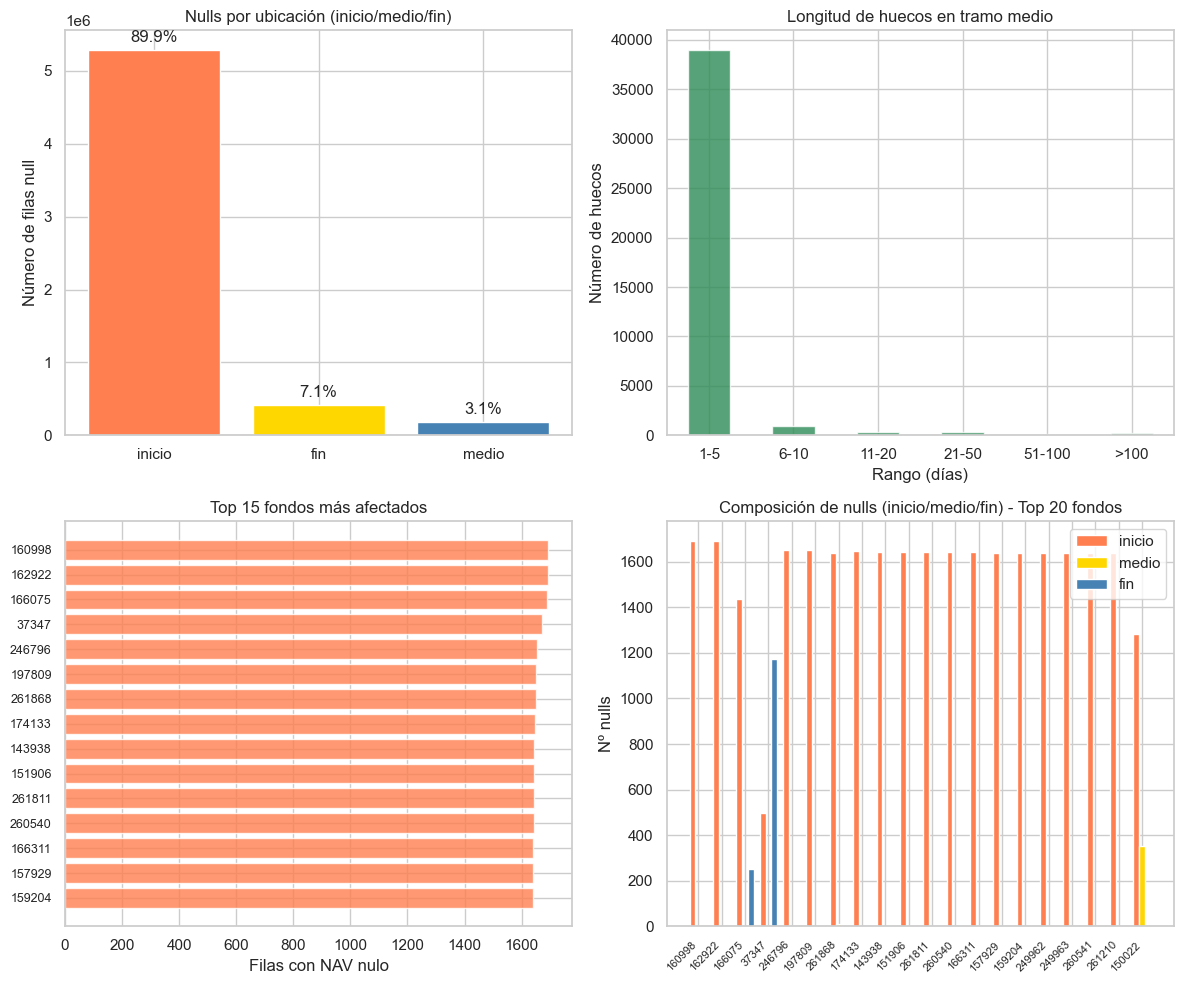


--- EVIDENCIA PARA DECISIÓN ---
Nulls en bordes (inicio+fin): 96.9%
Nulls en tramo medio: 3.1%
Huecos de 6-10 días (de 41,003 total): 915 (2.2%)


In [15]:
# =============================================================================
# 4.3 – Diagnóstico de nulls restantes
# =============================================================================
# Fuente: panel_diario_imputado.parquet (o daily_panel_imputed en memoria)
# Objetivo: Caracterizar nulls para decidir tratamiento posterior
# =============================================================================
# Cargar panel (priorizar parquet si existe)
PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_imputado.parquet"
if PARQUET_PATH.exists():
    panel = pd.read_parquet(PARQUET_PATH)
    print(f"Cargado desde: {PARQUET_PATH}")
else:
    panel = daily_panel_imputed
    print("Usando daily_panel_imputed en memoria")

fund_col = "allfunds_id" if "allfunds_id" in panel.columns else "isin"
date_col = "date"
panel[date_col] = pd.to_datetime(panel[date_col], errors="coerce")
panel = panel.sort_values([fund_col, date_col]).reset_index(drop=True)

# Solo filas con NAV nulo
null_rows = panel[panel["nav"].isna()].copy()
n_null_total = len(null_rows)
n_fondos = panel[fund_col].nunique()

# --- Dónde están los nulls (inicio / medio / fin) ---
valid_dates = (
    panel[panel["nav"].notna()]
    .groupby(fund_col)[date_col]
    .agg(["min", "max"])
    .rename(columns={"min": "primera_valido", "max": "ultima_valido"})
)

null_rows = null_rows.merge(valid_dates, left_on=fund_col, right_index=True, how="left")

null_rows["ubicacion"] = "medio"
null_rows.loc[null_rows[date_col] < null_rows["primera_valido"], "ubicacion"] = "inicio"
null_rows.loc[null_rows[date_col] > null_rows["ultima_valido"], "ubicacion"] = "fin"

dist_ubicacion = null_rows["ubicacion"].value_counts()
dist_ubicacion_pct = 100 * dist_ubicacion / n_null_total

# --- Longitud de huecos (solo en tramo medio) ---
null_medio = null_rows[null_rows["ubicacion"] == "medio"].copy()
null_medio = null_medio.sort_values([fund_col, date_col])


def gap_lengths_per_fund(df, fund_col, date_col):
    """Para cada fondo, calcula longitudes de huecos consecutivos."""
    gaps = []
    for fid, g in df.groupby(fund_col):
        g = g.sort_values(date_col)
        dates = g[date_col].values
        if len(dates) == 0:
            continue
        run = 1
        for i in range(1, len(dates)):
            d = (dates[i] - dates[i - 1]).astype("timedelta64[D]").astype(int)
            if d == 1:
                run += 1
            else:
                gaps.append({"fund": fid, "gap_dias": run})
                run = 1
        gaps.append({"fund": fid, "gap_dias": run})
    return pd.DataFrame(gaps)


gaps_df = gap_lengths_per_fund(null_medio, fund_col, date_col)

# Distribución de longitudes de hueco (7 bordes = 6 intervalos = 6 labels)
if len(gaps_df) > 0:
    dist_gaps = gaps_df["gap_dias"].value_counts().sort_index()
    bins = [0, 5, 10, 21, 51, 101, 10000]
    labels = ["1-5", "6-10", "11-20", "21-50", "51-100", ">100"]
    gaps_df["rango"] = pd.cut(gaps_df["gap_dias"], bins=bins, labels=labels, right=True)
    dist_rango = gaps_df["rango"].value_counts().sort_index()
else:
    dist_rango = pd.Series(dtype=int)
    dist_gaps = pd.Series(dtype=int)

# --- Fondos más afectados ---
por_fondo = null_rows.groupby(fund_col).agg(
    n_null=(date_col, "size"),
    n_inicio=("ubicacion", lambda x: (x == "inicio").sum()),
    n_medio=("ubicacion", lambda x: (x == "medio").sum()),
    n_fin=("ubicacion", lambda x: (x == "fin").sum()),
).reset_index()

n_filas_por_fondo = panel.groupby(fund_col).size().rename("n_filas")
por_fondo = por_fondo.merge(n_filas_por_fondo, left_on=fund_col, right_index=True)
por_fondo["pct_null"] = 100 * por_fondo["n_null"] / por_fondo["n_filas"]
por_fondo["pct_inicio"] = 100 * por_fondo["n_inicio"] / por_fondo["n_null"]
por_fondo["pct_medio"] = 100 * por_fondo["n_medio"] / por_fondo["n_null"]
por_fondo["pct_fin"] = 100 * por_fondo["n_fin"] / por_fondo["n_null"]

top_afectados = por_fondo.nlargest(20, "n_null")

# --- Salida ---
print("=" * 70)
print("4.3 – DIAGNÓSTICO DE NULLS RESTANTES")
print("=" * 70)
print(f"Panel: {len(panel):,} filas, {n_fondos:,} fondos")
print(f"Filas con NAV nulo: {n_null_total:,} ({100*n_null_total/len(panel):.2f}%)")
print("-" * 70)
print("UBICACIÓN DE NULLS (inicio/medio/fin):")
for u in ["inicio", "medio", "fin"]:
    n = dist_ubicacion.get(u, 0)
    p = dist_ubicacion_pct.get(u, 0)
    print(f"  {u:8s}: {n:>10,} ({p:5.1f}%)")
print("-" * 70)
print("LONGITUD DE HUECOS (tramo medio, días consecutivos):")
if len(dist_rango) > 0:
    for r, c in dist_rango.items():
        print(f"  {str(r):>6s}: {c:,} huecos")
else:
    print("  (sin huecos en tramo medio)")
print("-" * 70)
print("Top 10 fondos con más nulls restantes:")
display(top_afectados[[fund_col, "n_null", "pct_null", "n_inicio", "n_medio", "n_fin"]].head(10))
print("=" * 70)

# --- Gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Ubicación de nulls
ax1 = axes[0, 0]
ax1.bar(dist_ubicacion.index, dist_ubicacion.values, color=["coral", "gold", "steelblue"])
ax1.set_ylabel("Número de filas null")
ax1.set_title("Nulls por ubicación (inicio/medio/fin)")
for i, (k, v) in enumerate(dist_ubicacion.items()):
    ax1.text(i, v + max(dist_ubicacion) * 0.02, f"{dist_ubicacion_pct[k]:.1f}%", ha="center")

# 2. Distribución de longitud de huecos
ax2 = axes[0, 1]
if len(dist_rango) > 0:
    dist_rango.plot(kind="bar", ax=ax2, color="seagreen", alpha=0.8)
ax2.set_xlabel("Rango (días)")
ax2.set_ylabel("Número de huecos")
ax2.set_title("Longitud de huecos en tramo medio")
ax2.tick_params(axis="x", rotation=0)

# 3. Top 15 fondos con más nulls
ax3 = axes[1, 0]
top15 = por_fondo.nlargest(15, "n_null")
ax3.barh(range(len(top15)), top15["n_null"], color="coral", alpha=0.8)
ax3.set_yticks(range(len(top15)))
ax3.set_yticklabels(top15[fund_col].astype(str), fontsize=9)
ax3.set_xlabel("Filas con NAV nulo")
ax3.set_title("Top 15 fondos más afectados")
ax3.invert_yaxis()

# 4. Composición de nulls (inicio/medio/fin) - Top 20 fondos
ax4 = axes[1, 1]
top20 = por_fondo.nlargest(20, "n_null")
x = range(len(top20))
w = 0.25
ax4.bar([i - w for i in x], top20["n_inicio"], w, label="inicio", color="coral")
ax4.bar(x, top20["n_medio"], w, label="medio", color="gold")
ax4.bar([i + w for i in x], top20["n_fin"], w, label="fin", color="steelblue")
ax4.set_xticks(x)
ax4.set_xticklabels(top20[fund_col].astype(str), rotation=45, ha="right", fontsize=8)
ax4.set_ylabel("Nº nulls")
ax4.set_title("Composición de nulls (inicio/medio/fin) - Top 20 fondos")
ax4.legend()

plt.tight_layout()
plt.show()

# --- Resumen para decisión ---
pct_inicio = dist_ubicacion_pct.get("inicio", 0)
pct_medio = dist_ubicacion_pct.get("medio", 0)
pct_fin = dist_ubicacion_pct.get("fin", 0)
n_huecos_6_10 = dist_rango.get("6-10", 0) if len(dist_rango) > 0 else 0
n_huecos_total = dist_rango.sum() if len(dist_rango) > 0 else 0
pct_huecos_6_10 = 100 * n_huecos_6_10 / n_huecos_total if n_huecos_total > 0 else 0

print("\n--- EVIDENCIA PARA DECISIÓN ---")
print(f"Nulls en bordes (inicio+fin): {pct_inicio + pct_fin:.1f}%")
print(f"Nulls en tramo medio: {pct_medio:.1f}%")
print(f"Huecos de 6-10 días (de {n_huecos_total:,} total): {n_huecos_6_10:,} ({pct_huecos_6_10:.1f}%)")


### 4.4 – Recorte temporal por fondo (eliminación de nulls estructurales en bordes)

Evidencia que motiva la decisión (4.3)

- **89,9%** de los nulls restantes están en el **inicio** (antes del primer NAV válido).
- **7,1%** en el **fin** (después del último NAV válido).
- **3,1%** en el tramo **medio**.

En total, **~97%** de los nulls son estructurales en los bordes, no en el medio de la serie.

Origen del problema

El panel se construye con un calendario global (p. ej. desde 2016-01-05). Cada fondo tiene fila para cada día del rango, aunque aún no tuviera datos. Así:

- Fondos que empiezan en 2018 tienen nulls en 2016–2017.
- Fondos que terminan en 2019 tienen nulls desde 2020 hasta el final del panel.

Esos nulls no representan huecos reales, sino ausencia del fondo en el universo en esas fechas.

Propuesta de tratamiento

**Regla A – Entrada:** Un fondo entra en el dataset en la fecha de su **primer NAV válido**. Se eliminan todas las filas anteriores (nulls de inicio).

**Regla B – Salida:** Un fondo sale del dataset solo cuando, **después** de su último NAV válido, hay muchos nulls consecutivos (p. ej. 30+ días) hasta el final de la serie. Así evitamos tratar como salida un hueco puntual en el medio: si el fondo vuelve a tener datos más adelante, no se considera salido. Solo se recorta cuando el tramo final de nulls es largo y sugiere que el fondo dejó de publicar.

**Regla C – Fondos con huecos en medio:** Los fondos que tienen huecos de NAV nulo **entre** su primer y último NAV válido se **excluyen por completo** del dataset. Tras el ffill no hay una explicación razonable para esos huecos; además representan un porcentaje muy bajo (~3,1%) del total de nulls. Se prioriza eliminar esos fondos antes que imputar o recortar huecos internos.

 Orden en el pipeline

Aplicar **después** de 4.2 (ffill) y 4.3 (diagnóstico), sobre `panel_diario_imputado.parquet`.

Cargado desde: data\daily_universe\panel_diario_imputado.parquet
4.4 – RECORTE TEMPORAL POR FONDO

--- REGLA C: Fondos con huecos en medio (excluidos) ---
  Fondos excluidos: 3,992
  Filas eliminadas: 8,063,840

--- REGLAS A y B: Recorte de bordes ---
  Filas antes recorte: 40,876,720
  Filas después recorte: 36,172,388
  Filas eliminadas (bordes): 4,704,332

--- COMPARATIVA GLOBAL ---
----------------------------------------------------------------------
Métrica                       Antes (4.2)   Después (4.4)          Cambio
----------------------------------------------------------------------
Filas                          48,940,560      36,172,388     -12,768,172
Fondos                             24,228          20,236          -3,992
NAV nulos                       5,889,020               0      -5,889,020
% null                             12.03%           0.00%         -12.03%


,etapa,n_filas,n_fondos,n_nav_null,pct_null
0,4.2 imputado,48940560,24228,5889020,12.033005
1,4.4 recortado,36172388,20236,0,0.000000


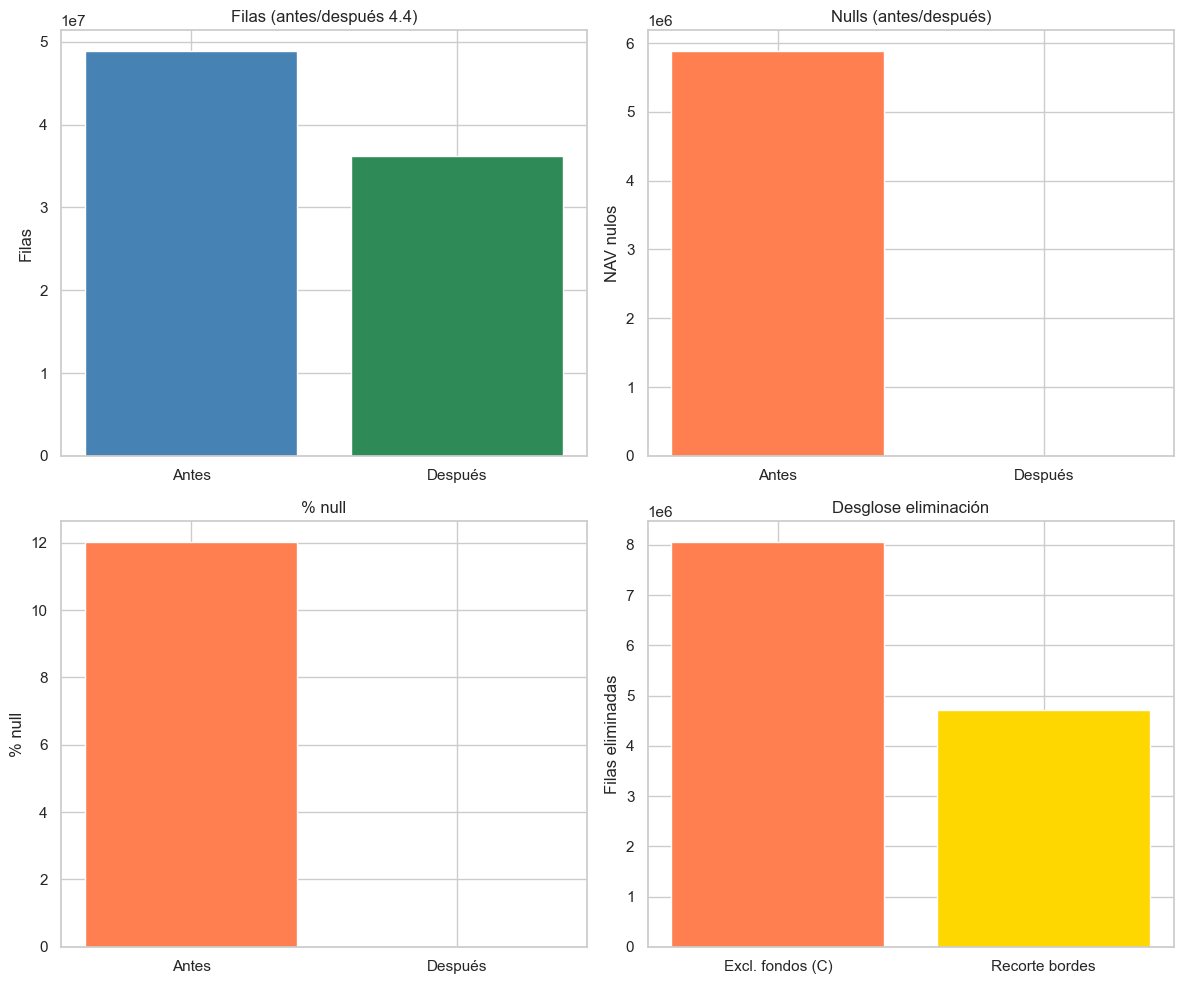


Guardado: data\daily_universe\panel_diario_recortado.parquet


In [16]:
# =============================================================================
# 4.4 – Recorte temporal por fondo (VERSIÓN OPTIMIZADA)
# =============================================================================


PARQUET_PATH = Path("data") / "daily_universe" / "panel_diario_imputado.parquet"
if PARQUET_PATH.exists():
    panel = pd.read_parquet(PARQUET_PATH)
    print(f"Cargado desde: {PARQUET_PATH}")
else:
    panel = daily_panel_imputed.copy()
    print("Usando daily_panel_imputed en memoria")

fund_col = "allfunds_id" if "allfunds_id" in panel.columns else "isin"
date_col = "date"
panel[date_col] = pd.to_datetime(panel[date_col], errors="coerce")
panel = panel.sort_values([fund_col, date_col]).reset_index(drop=True)

# --- Estado INICIAL ---
n_filas_antes = len(panel)
n_fondos_antes = panel[fund_col].nunique()
n_null_antes = panel["nav"].isna().sum()
pct_null_antes = 100 * n_null_antes / n_filas_antes

# --- Bounds por fondo (vectorizado) ---
valid = panel[panel["nav"].notna()]
primera = valid.groupby(fund_col)[date_col].min().rename("primera_valido")
ultima = valid.groupby(fund_col)[date_col].max().rename("ultima_valido")
bounds = pd.concat([primera, ultima], axis=1)

sin_datos = set(panel[fund_col].unique()) - set(valid[fund_col].unique())
bounds = bounds[~bounds.index.isin(sin_datos)]

# --- Regla C: fondos con huecos en medio (vectorizado) ---
panel_b = panel.merge(bounds, left_on=fund_col, right_index=True, how="inner")
en_rango = (panel_b[date_col] >= panel_b["primera_valido"]) & (panel_b[date_col] <= panel_b["ultima_valido"])
panel_medio = panel_b[en_rango]
fondos_con_huecos = set(panel_medio[panel_medio["nav"].isna()][fund_col].unique())
fondos_excluir = fondos_con_huecos | sin_datos

panel_sin_huecos = panel[~panel[fund_col].isin(fondos_excluir)].copy()
n_fondos_excl_C = len(fondos_excluir)
n_filas_excl_C = n_filas_antes - len(panel_sin_huecos)

# --- Reglas A y B: recorte (vectorizado) ---
bounds_ok = bounds[~bounds.index.isin(fondos_excluir)]
panel_m = panel_sin_huecos.merge(bounds_ok, left_on=fund_col, right_index=True, how="inner")
panel_recortado = panel_m[
    (panel_m[date_col] >= panel_m["primera_valido"]) & 
    (panel_m[date_col] <= panel_m["ultima_valido"])
].drop(columns=["primera_valido", "ultima_valido"])

# --- Estado FINAL ---
n_filas_despues = len(panel_recortado)
n_fondos_despues = panel_recortado[fund_col].nunique()
n_null_despues = panel_recortado["nav"].isna().sum()
pct_null_despues = 100 * n_null_despues / n_filas_despues if n_filas_despues > 0 else 0

# --- Salida ---
print("=" * 70)
print("4.4 – RECORTE TEMPORAL POR FONDO")
print("=" * 70)
print("\n--- REGLA C: Fondos con huecos en medio (excluidos) ---")
print(f"  Fondos excluidos: {n_fondos_excl_C:,}")
print(f"  Filas eliminadas: {n_filas_excl_C:,}")

print("\n--- REGLAS A y B: Recorte de bordes ---")
print(f"  Filas antes recorte: {len(panel_sin_huecos):,}")
print(f"  Filas después recorte: {n_filas_despues:,}")
print(f"  Filas eliminadas (bordes): {len(panel_sin_huecos) - n_filas_despues:,}")

print("\n--- COMPARATIVA GLOBAL ---")
print("-" * 70)
print(f"{'Métrica':<25} {'Antes (4.2)':>15} {'Después (4.4)':>15} {'Cambio':>15}")
print("-" * 70)
print(f"{'Filas':<25} {n_filas_antes:>15,} {n_filas_despues:>15,} {n_filas_despues - n_filas_antes:>15,}")
print(f"{'Fondos':<25} {n_fondos_antes:>15,} {n_fondos_despues:>15,} {n_fondos_despues - n_fondos_antes:>15,}")
print(f"{'NAV nulos':<25} {n_null_antes:>15,} {n_null_despues:>15,} {n_null_despues - n_null_antes:>15,}")
print(f"{'% null':<25} {pct_null_antes:>14.2f}% {pct_null_despues:>14.2f}% {pct_null_despues - pct_null_antes:>14.2f}%")
print("=" * 70)

resumen_pipeline = pd.DataFrame({
    "etapa": ["4.2 imputado", "4.4 recortado"],
    "n_filas": [n_filas_antes, n_filas_despues],
    "n_fondos": [n_fondos_antes, n_fondos_despues],
    "n_nav_null": [n_null_antes, n_null_despues],
    "pct_null": [pct_null_antes, pct_null_despues],
})
display(resumen_pipeline)

# --- Gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax1 = axes[0, 0]
ax1.bar(["Antes", "Después"], [n_filas_antes, n_filas_despues], color=["steelblue", "seagreen"])
ax1.set_ylabel("Filas")
ax1.set_title("Filas (antes/después 4.4)")

ax2 = axes[0, 1]
ax2.bar(["Antes", "Después"], [n_null_antes, n_null_despues], color=["coral", "seagreen"])
ax2.set_ylabel("NAV nulos")
ax2.set_title("Nulls (antes/después)")

ax3 = axes[1, 0]
ax3.bar(["Antes", "Después"], [pct_null_antes, pct_null_despues], color=["coral", "seagreen"])
ax3.set_ylabel("% null")
ax3.set_title("% null")

ax4 = axes[1, 1]
ax4.bar(["Excl. fondos (C)", "Recorte bordes"], [n_filas_excl_C, len(panel_sin_huecos) - n_filas_despues], color=["coral", "gold"])
ax4.set_ylabel("Filas eliminadas")
ax4.set_title("Desglose eliminación")
plt.tight_layout()
plt.show()

# --- Guardar ---
panel_final_44 = panel_recortado.copy()
OUT_DIR = Path("data") / "daily_universe"
OUT_DIR.mkdir(parents=True, exist_ok=True)
panel_final_44.to_parquet(OUT_DIR / "panel_diario_recortado.parquet", index=False)
print(f"\nGuardado: {OUT_DIR / 'panel_diario_recortado.parquet'}")

## 5. Feature engineering

En este bloque se transforman los NAVs limpios (`panel_diario_recortado.parquet`) y los factores 
Fama-French de Asia (`factores_unificados.csv`) en una matriz de features y variable objetivo 
lista para modelado supervisado.

El enfoque se inspira directamente en dos secciones del notebook de referencia 
`MIAX ML - 03 Linear Regression.ipynb`:

1. **CAPM / Fama-French** (sección "Computing the CAPM β"): regresión OLS de retornos de cada 
   fondo sobre factores FF de Asia Pacific ex Japan → extrae betas (β_mkt, β_smb, β_hml, β_wml), 
   alpha (α) y R². Estos miden **cuánto expuesto está cada fondo al mercado asiático**, 
   que es la pieza central de la tesis de inversión.

2. **Stock Picking** (sección "Playing with financial assets: Stock Picking"): features de 
   momentum y volatilidad a distintos horizontes + clasificación binaria (outperform vs 
   underperform) → se adapta de acciones individuales a fondos de inversión.

---

Conexión con la tesis

> *"As portfolio managers, we believe the Asian market will perform well next year; therefore, 
> we aim to position our fund of funds with a clear bias toward this market."*

Para materializar esta tesis necesitamos responder dos preguntas:
- **¿Qué fondos están expuestos a Asia?** → features de exposición factorial (5.4)
- **¿Cuáles de esos fondos lo harán mejor?** → features de momentum/volatilidad (5.3) + modelo predictivo (sección 6)

---

 Estructura de la sección

| Subsección | Qué hace | Tipo de feature |
|------------|----------|-----------------|
| **5.1** | Carga de panel limpio y factores; pivote a formato ancho; alineación temporal | Preparación |
| **5.2** | Remuestreo semanal (miércoles); log-retornos; retornos en exceso (R - RF) | Preparación |
| **5.3** | Momentum (52w, 26w, 4w) y volatilidad (52w, 26w, 4w) rolling por fondo | 6 features **dinámicas** (cambian cada semana) |
| **5.4** | Regresión Fama-French por fondo: α, β_mkt, β_smb, β_hml, β_wml, R² | 6 features **estáticas** (caracterizan al fondo) |
| **5.5** | Variable objetivo: ¿el fondo supera la mediana cross-seccional en las próximas 4 semanas? | Target binario `y ∈ {0, 1}` |
| **5.6** | Ensamblaje en formato largo, merge de features dinámicas + estáticas + target, limpieza de NaN | Matriz final `X` (12 features) e `y` |

---

 Decisiones justificadas

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| **Frecuencia temporal** | Semanal (miércoles) | Reduce ruido de retornos diarios; es la misma frecuencia del notebook de referencia (Stock Picking); mitiga problemas de fondos con huecos puntuales intra-semana |
| **Retornos** | Log-retornos `ln(NAV_t / NAV_{t-1})` | Propiedades aditivas en el tiempo (la suma de log-retornos = retorno acumulado); es la convención del notebook de referencia |
| **Factores FF** | Divididos por 100 (a decimales) | Los datos de Ken French vienen en porcentaje (ej. -1.38 = -1.38%); se convierten a decimales para ser coherentes con los log-retornos |
| **Agregación semanal de factores** | Suma de retornos diarios | Los factores FF son retornos diarios; su suma dentro de la semana da el retorno semanal del factor |
| **Features de momentum** | Rolling sum de log-retornos (52w, 26w, 4w) | Mide tendencia reciente a 12m, 6m, 1m; misma definición que `compute_features()` del notebook de referencia |
| **Features de volatilidad** | Rolling std de log-retornos (52w, 26w, 4w) | Mide riesgo reciente; complementa momentum; misma definición que referencia |
| **Betas FF** | Regresión OLS full-sample por fondo | Captura la naturaleza estructural del fondo (exposición a Asia, tamaño, valor, momentum); se estima una vez y se usa como feature estática |
| **Mínimo de observaciones** | 52 semanas (~1 año) | Un fondo necesita al menos 1 año de datos para estimar betas y features

### 5.1 – Carga de datos limpios y factores

Se carga el panel limpio (`panel_diario_recortado.parquet`, resultado de la sección 4 con 0% nulls 
y 20,236 fondos) y los factores Fama-French unificados (`factores_unificados.csv`, con Mkt-RF, SMB, 
HML, RF y WML de Asia Pacific ex Japan).

Se alinean temporalmente ambos datasets al rango común de fechas y se pivota el panel de NAVs a 
formato ancho (`date × isin`) para poder operar vectorizadamente sobre todos los fondos a la vez.

**Decisiones:**

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Factores divididos entre 100 | `Mkt-RF / 100`, `SMB / 100`, etc. | Los datos de Ken French vienen en porcentaje (ej. -1.38 = -1.38%). Se convierten a decimales para ser coherentes con los log-retornos de NAV |
| Pivote a formato ancho | `date` como índice, `isin` como columnas, `nav` como valores | Permite cálculos rolling vectorizados (momentum, volatilidad) sobre todos los fondos simultáneamente sin bucles |

In [17]:
# =============================================================================
# 5.1 – Carga de datos limpios y factores
# =============================================================================


# --- Cargar panel limpio ---
panel = pd.read_parquet(Path("data") / "daily_universe" / "panel_diario_recortado.parquet")
panel["date"] = pd.to_datetime(panel["date"])

# --- Cargar factores ---
factors = pd.read_csv(Path("data") / "factors" / "factores_unificados.csv")
factors["date"] = pd.to_datetime(factors["date"])

# --- Alinear rango temporal ---
common_min = max(panel["date"].min(), factors["date"].min())
common_max = min(panel["date"].max(), factors["date"].max())
panel = panel[(panel["date"] >= common_min) & (panel["date"] <= common_max)].copy()
factors = factors[(factors["date"] >= common_min) & (factors["date"] <= common_max)].copy()

# --- Factores a decimales (vienen en %) ---
factor_cols = ["Mkt-RF", "SMB", "HML", "WML"]
factors_daily = factors.set_index("date").copy()
for c in factor_cols + ["RF"]:
    factors_daily[c] = factors_daily[c] / 100

# --- Pivotar NAVs a formato ancho: date × isin ---
navs_wide = panel.pivot_table(index="date", columns="isin", values="nav", aggfunc="last")
navs_wide = navs_wide.sort_index()

print(f"NAVs wide: {navs_wide.shape[0]:,} días × {navs_wide.shape[1]:,} fondos")
print(f"Factores daily: {len(factors_daily):,} días")
print(f"Rango: {common_min.date()} → {common_max.date()}")

factors_daily.head()

NAVs wide: 2,020 días × 20,236 fondos
Factores daily: 1,444 días
Rango: 2016-01-05 → 2021-07-16


,Mkt-RF,SMB,HML,RF,WML
date,,,,,
2016-01-05,-0.0094,0.0037,0.0082,0.0,0.0001
2016-01-06,-0.0165,0.0052,0.0044,0.0,0.0057
2016-01-07,-0.0264,0.0025,0.0060,0.0,0.0020
2016-01-08,-0.0055,0.0061,0.0043,0.0,0.0058
2016-01-11,-0.0138,-0.0022,-0.0054,0.0,-0.0028


### 5.2 – Remuestreo semanal y cálculo de log-retornos

Se remuestrea a **frecuencia semanal (miércoles)** siguiendo exactamente el enfoque del notebook
de referencia (`MIAX ML - 03`, sección Stock Picking: `px_comp.resample("W-WED").last()`).

**¿Por qué semanal y no diario?**

| Criterio | Diario | Semanal |
|----------|--------|---------|
| Ruido | Alto (microestructura, bid-ask) | Suavizado al agregar 5 sesiones |
| Autocorrelación | Frecuente en fondos ilíquidos → viola asunciones del modelo | Se reduce significativamente |
| Huecos puntuales | Sensible a festivos → más NaN | Un fondo con 3/5 días válidos tiene NAV semanal válido |
| Tamaño del dataset | ~28M filas (inmanejable) | ~4.8M filas (~6× menor) |
| Horizonte del fund of funds | Un fund of funds no rebalancea a diario | Predicción a 4 semanas = horizonte natural de rebalanceo mensual |
| Riesgo de overfitting | Más filas ruidosas → memoriza ruido | Menos filas, más limpias → aprende patrones reales |

**Conclusión:** para un fund of funds con horizonte mensual, la frecuencia semanal ofrece mejor 
relación señal/ruido, menor coste computacional y mayor coherencia con el horizonte de predicción.

**Cómo se calculan los retornos y factores semanales:**

- **NAVs:** se toma el **último NAV** de cada semana (`resample("W-WED").last()`).
- **Log-retornos de fondos:** `ln(NAV_t / NAV_{t-1})` = `diff()` sobre `log(NAV)`.
- **Factores FF semanales:** **suma** de los retornos diarios del factor dentro de la semana, 
  porque los retornos de factores son aditivos en escala decimal.




In [26]:
# =============================================================================
# 5.2 – Remuestreo semanal y log-retornos
# =============================================================================

# --- NAVs semanales (último NAV de la semana, miércoles) ---
navs_weekly = navs_wide.resample("W-WED").last()

# --- Factores semanales (suma de retornos diarios en la semana) ---
factors_weekly = factors_daily[factor_cols].resample("W-WED").sum()
rf_weekly = factors_daily[["RF"]].resample("W-WED").sum()

# --- Alinear índices temporales ---
common_idx = navs_weekly.index.intersection(factors_weekly.index)
navs_weekly = navs_weekly.loc[common_idx]
factors_weekly = factors_weekly.loc[common_idx]
rf_weekly = rf_weekly.loc[common_idx]

# --- Log-retornos semanales de fondos ---
ret_weekly = np.log(navs_weekly).diff()
ret_weekly = ret_weekly.iloc[1:]  # primera fila es NaN por diff()

# --- Retornos en exceso (retorno fondo - RF) ---
factors_weekly = factors_weekly.loc[ret_weekly.index]
rf_weekly = rf_weekly.loc[ret_weekly.index]
excess_ret_weekly = ret_weekly.sub(rf_weekly["RF"], axis=0)

# --- Resumen ---
n_weeks = ret_weekly.shape[0]
n_funds = ret_weekly.shape[1]
# Fondos con al menos 52 semanas de datos válidos
funds_with_52w = (ret_weekly.notna().sum(axis=0) >= 52).sum()

print(f"Semanas de retornos: {n_weeks}")
print(f"Fondos totales: {n_funds:,}")
print(f"Fondos con ≥52 semanas válidas: {funds_with_52w:,}")
print(f"Rango semanal: {ret_weekly.index[0].date()} → {ret_weekly.index[-1].date()}")

ret_weekly.head()

Semanas de retornos: 289
Fondos totales: 20,236
Fondos con ≥52 semanas válidas: 20,232
Rango semanal: 2016-01-13 → 2021-07-21


isin,AT0000495304,AT0000497268,AT0000607270,AT0000673165,AT0000673181,AT0000673199,AT0000673306,AT0000712534,AT0000740667,AT0000745872,...,LU2134693808,LU2166021886,LU2168317308,LU2171252351,LU2176897911,LU2176898059,LU2176898133,LU2176899297,LU2183894653,NL0000289783
date,,,,,,,,,,,,,,,,,,,,,
2016-01-13,-0.034183,-0.057093,-0.003384,-0.113655,-0.049308,-0.008677,-0.006248,-0.003625,-0.015305,-0.052455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.049344
2016-01-20,-0.028707,-0.027244,-0.004928,-0.090886,-0.048896,-0.009048,-0.007739,-0.005647,-0.010719,-0.021981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.049922
2016-01-27,0.024844,-0.016054,0.004815,0.010965,0.031665,0.006236,0.005685,0.004542,0.004840,-0.003180,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021562
2016-02-03,-0.008876,0.016256,0.006758,-0.093947,0.023143,0.012357,0.004602,0.007036,0.011959,0.023496,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008439
2016-02-10,-0.082840,-0.033196,-0.000281,-0.089232,-0.046540,-0.008377,-0.001661,-0.001152,-0.012672,-0.039203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.074760


### 5.3 – Features dinámicas: momentum y volatilidad

Siguiendo el enfoque del notebook de referencia (`compute_features` en la sección Stock Picking
de `MIAX ML - 03`), se calculan **6 features rolling** para cada fondo en cada semana.
Estas features capturan dos dimensiones complementarias del comportamiento reciente del fondo:

- **Momentum** (tendencia): ¿el fondo viene subiendo o bajando?
- **Volatilidad** (riesgo): ¿el fondo es estable o errático?

Ambas se miden a tres horizontes temporales distintos para capturar señales de corto, medio y largo plazo.

**Features calculadas:**

| Feature | Cálculo | Horizonte | Qué mide | Ejemplo de interpretación |
|---------|---------|-----------|----------|--------------------------|
| `momentum_52w` | Σ log-retornos últimas 52 semanas | ~12 meses | Tendencia anual | `+0.15` = fondo subió ~15% en el último año |
| `momentum_26w` | Σ log-retornos últimas 26 semanas | ~6 meses | Tendencia semestral | `-0.05` = fondo bajó ~5% en 6 meses |
| `momentum_4w` | Σ log-retornos últimas 4 semanas | ~1 mes | Tendencia reciente | `+0.02` = subida reciente del ~2% |
| `volatility_52w` | Std de log-retornos últimas 52 semanas | ~12 meses | Riesgo anual | `0.03` = desviación típica semanal del 3% |
| `volatility_26w` | Std de log-retornos últimas 26 semanas | ~6 meses | Riesgo semestral | Valores altos → fondo muy volátil últimamente |
| `volatility_4w` | Std de log-retornos últimas 4 semanas | ~1 mes | Riesgo reciente | Pico de volatilidad reciente puede indicar estrés |

**¿Por qué estos tres horizontes?**

El notebook de referencia usa exactamente estos tres (12m, 6m, 1m) porque capturan diferentes
regímenes de mercado. Un fondo puede tener buen momentum a 12 meses pero estar cayendo en el
último mes (señal de cambio de tendencia), o viceversa. Dar al modelo los tres horizontes le 
permite aprender estos patrones cruzados.

**¿Por qué momentum Y volatilidad?**

Son complementarios: dos fondos con el mismo momentum +10% pueden ser muy distintos si uno 
subió gradualmente (baja volatilidad → señal más fiable) y otro subió un 20% y bajó un 10% 
(alta volatilidad → señal menos fiable). El modelo necesita ambas dimensiones para distinguirlos.

**Corrección temporal (sin look-ahead):**

Todas las features usan `rolling(window=N)`, que por defecto mira solo hacia atrás: para la 
semana `t`, solo se usan datos de las semanas `t-N+1` a `t`. Nunca se usa información futura.
Las primeras 51 semanas producen NaN natural (no hay 52 semanas de historial), que se filtrarán
en la sección 5.6 al ensamblar la matriz final.

In [27]:
# =============================================================================
# 5.3 – Features dinámicas: momentum y volatilidad
# =============================================================================

WEEKS_52 = 52  # ~12 meses
WEEKS_26 = 26  # ~6 meses
WEEKS_4  = 4   # ~1 mes

# Momentum = retorno log acumulado en ventana (suma de log-retornos)
momentum_52w = ret_weekly.rolling(window=WEEKS_52, min_periods=WEEKS_52).sum()
momentum_26w = ret_weekly.rolling(window=WEEKS_26, min_periods=WEEKS_26).sum()
momentum_4w  = ret_weekly.rolling(window=WEEKS_4,  min_periods=WEEKS_4).sum()

# Volatilidad = std de log-retornos en ventana
volatility_52w = ret_weekly.rolling(window=WEEKS_52, min_periods=WEEKS_52).std(ddof=1)
volatility_26w = ret_weekly.rolling(window=WEEKS_26, min_periods=WEEKS_26).std(ddof=1)
volatility_4w  = ret_weekly.rolling(window=WEEKS_4,  min_periods=WEEKS_4).std(ddof=1)

# Primera fecha con todas las features (ventana 52w)
first_valid = momentum_52w.dropna(how="all").index[0]
print(f"Primera fecha con features completas (ventana 52w): {first_valid.date()}")
print(f"Semanas con features posibles: {(ret_weekly.index >= first_valid).sum()}")


Primera fecha con features completas (ventana 52w): 2017-01-04
Semanas con features posibles: 238


### 5.4 – Features de exposición a factores Fama-French (Asia)

Esta es la **pieza clave para la tesis de inversión**. El objetivo es cuantificar cuánto 
depende cada fondo del mercado asiático y de sus factores de riesgo.

Siguiendo el modelo CAPM/Fama-French del notebook de referencia (`MIAX ML - 03`, sección 
"Computing the CAPM β"), se estima para cada fondo la siguiente regresión OLS:

$$R_{i,t} - R_f = \alpha_i + \beta_{mkt,i}(Mkt\text{-}RF)_t + \beta_{smb,i} \cdot SMB_t + \beta_{hml,i} \cdot HML_t + \beta_{wml,i} \cdot WML_t + \varepsilon_{i,t}$$

Donde los factores son de **Asia Pacific ex Japan** (descargados de Ken French en la sección 2).

**¿Qué nos dice cada coeficiente?**

| Coeficiente | Interpretación | Ejemplo |
|-------------|---------------|---------|
| `alpha (α)` | Rendimiento extra no explicado por los factores → "habilidad del gestor" o exposición a factores no modelados | `α > 0` → el fondo genera valor más allá de la exposición a Asia |
| `beta_mkt (β_mkt)` | Sensibilidad al mercado asiático en su conjunto | `β_mkt = 0.8` → si Asia sube 1%, el fondo sube ~0.8%. `β_mkt ≈ 0` → el fondo no está expuesto a Asia |
| `beta_smb (β_smb)` | Sesgo de tamaño en Asia | `> 0` → prefiere small caps asiáticas; `< 0` → prefiere large caps |
| `beta_hml (β_hml)` | Sesgo valor/crecimiento en Asia | `> 0` → sesgo value; `< 0` → sesgo growth |
| `beta_wml (β_wml)` | Sesgo momentum en Asia | `> 0` → sigue tendencias del mercado asiático |
| `R²` | Proporción de la varianza del fondo explicada por los factores Asia | `R² = 0.70` → el 70% del comportamiento del fondo se explica por factores asiáticos → muy "asiático". `R² = 0.02` → el fondo prácticamente no invierte en Asia |

**¿Cómo conecta con la tesis?**

> *"We believe the Asian market will perform well → position our fund of funds with a clear 
> bias toward this market."*

- Un fondo con **alto R²** y **alto β_mkt** está muy expuesto a Asia → si Asia sube, este fondo sube con ella → es el candidato ideal.
- Un fondo con **bajo R²** probablemente invierte en Europa, USA u otras regiones → los factores asiáticos no explican su comportamiento → menos útil para nuestra tesis.
- Los otros betas (SMB, HML, WML) refinan la selección: permiten distinguir, dentro de los fondos asiáticos, cuáles tienen sesgo value, growth, small/large cap o momentum.

**Decisiones de implementación:**

| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Enfoque | Full-sample (una regresión por fondo usando todo su historial) | Más robusto que rolling con pocas observaciones; captura la naturaleza estructural del fondo |
| Tipo de feature | Estática (un valor por fondo, no cambia por semana) | Los betas FF representan *qué tipo de fondo es*, no su estado coyuntural — eso ya lo capturan momentum y volatilidad |
| Mínimo de observaciones | 52 semanas (~1 año) | Con menos datos la regresión es inestable y los betas no son fiables |
| Implementación | `np.linalg.lstsq(X, Y)` fondo a fondo con máscara de NaN | Resuelve el sistema OLS para cada fondo individualmente, ignorando semanas con NaN en ese fondo |

Calculando betas Fama-French para todos los fondos...

Fondos con betas FF válidos: 20,232 / 20,236

Distribución de R² (exposición a factores Asia):


count    20232.000000
mean         0.482604
std          0.182127
min          0.000348
10%          0.194746
25%          0.379389
50%          0.516566
75%          0.609603
90%          0.693537
max          0.955316
Name: r2, dtype: float64


Distribución de beta_mkt (sensibilidad al mercado Asia):


count    20232.000000
mean         0.507435
std          0.339489
min         -8.715447
10%          0.090322
25%          0.223354
50%          0.478175
75%          0.767936
90%          0.936301
max          4.409432
Name: beta_mkt, dtype: float64

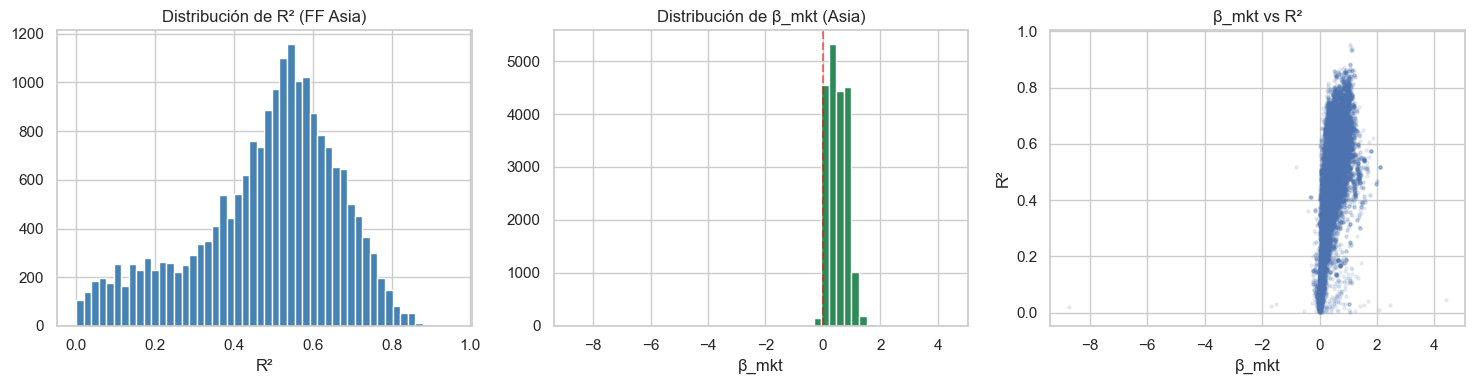

In [28]:
# =============================================================================
# 5.4 – Exposición a factores FF (regresión por fondo, vectorizada)
# =============================================================================

def compute_ff_betas(excess_returns, factors_df, min_obs=52):
    """
    Regresión Fama-French para todos los fondos a la vez (vectorizada).
    
    Parameters
    ----------
    excess_returns : DataFrame (T × N_funds) - retornos en exceso semanales
    factors_df : DataFrame (T × 4) - Mkt-RF, SMB, HML, WML semanales
    min_obs : int - mínimo de observaciones no-NaN por fondo
    
    Returns
    -------
    DataFrame con columnas: alpha, beta_mkt, beta_smb, beta_hml, beta_wml, r2, n_obs
    """
    # Alinear índices
    common_idx = excess_returns.index.intersection(factors_df.index)
    Y = excess_returns.loc[common_idx].copy()
    X_raw = factors_df.loc[common_idx, ["Mkt-RF", "SMB", "HML", "WML"]].copy()
    
    # Añadir constante (alpha)
    X = sm.add_constant(X_raw).values  # (T, 5)
    
    funds = Y.columns
    results = []
    
    for fund in funds:
        y = Y[fund].values
        mask = ~np.isnan(y)
        n_valid = mask.sum()
        
        if n_valid < min_obs:
            results.append({
                "isin": fund, "alpha": np.nan, "beta_mkt": np.nan,
                "beta_smb": np.nan, "beta_hml": np.nan, "beta_wml": np.nan,
                "r2": np.nan, "n_obs": n_valid
            })
            continue
        
        y_clean = y[mask]
        X_clean = X[mask]
        
        try:
            betas, residuals, rank, sv = np.linalg.lstsq(X_clean, y_clean, rcond=None)
            y_hat = X_clean @ betas
            ss_res = ((y_clean - y_hat) ** 2).sum()
            ss_tot = ((y_clean - y_clean.mean()) ** 2).sum()
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            
            results.append({
                "isin": fund,
                "alpha": betas[0],
                "beta_mkt": betas[1],
                "beta_smb": betas[2],
                "beta_hml": betas[3],
                "beta_wml": betas[4],
                "r2": r2,
                "n_obs": n_valid,
            })
        except Exception:
            results.append({
                "isin": fund, "alpha": np.nan, "beta_mkt": np.nan,
                "beta_smb": np.nan, "beta_hml": np.nan, "beta_wml": np.nan,
                "r2": np.nan, "n_obs": n_valid
            })
    
    return pd.DataFrame(results).set_index("isin")

# Calcular betas FF para todos los fondos
print("Calculando betas Fama-French para todos los fondos...")
ff_betas = compute_ff_betas(excess_ret_weekly, factors_weekly, min_obs=52)

# Resumen
n_valid_betas = ff_betas["r2"].notna().sum()
print(f"\nFondos con betas FF válidos: {n_valid_betas:,} / {len(ff_betas):,}")
print(f"\nDistribución de R² (exposición a factores Asia):")
display(ff_betas["r2"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

print(f"\nDistribución de beta_mkt (sensibilidad al mercado Asia):")
display(ff_betas["beta_mkt"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ff_betas["r2"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de R² (FF Asia)")
axes[0].set_xlabel("R²")

axes[1].hist(ff_betas["beta_mkt"].dropna(), bins=50, color="seagreen", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Distribución de β_mkt (Asia)")
axes[1].set_xlabel("β_mkt")

axes[2].scatter(ff_betas["beta_mkt"], ff_betas["r2"], alpha=0.1, s=5)
axes[2].set_xlabel("β_mkt")
axes[2].set_ylabel("R²")
axes[2].set_title("β_mkt vs R²")

plt.tight_layout()
plt.show()

### 5.5 – Definición de variable objetivo

Se define como variable objetivo el **retorno logarítmico acumulado de las próximas 4 semanas** 
(~1 mes) para cada fondo. Es una variable **continua**, lo que convierte el problema en una 
**regresión lineal**.

$$y_{i,t} = \sum_{k=1}^{4} r_{i,t+k}$$

Donde $r_{i,t+k}$ es el log-retorno semanal del fondo $i$ en la semana $t+k$.

**¿Por qué regresión y no clasificación?**

- La regresión predice directamente **cuánto** subirá o bajará cada fondo, no solo si será 
  mejor que la mediana. Esto permite construir el fund of funds ordenando fondos por retorno 
  predicho y seleccionando los mejores.
- Está alineado con el enfoque CAPM/ElasticNet del notebook de referencia (`MIAX ML - 03`), 
  donde se predice un retorno continuo.
- La interpretación de los coeficientes es más directa: cada β indica cuántos puntos de 
  retorno futuro aporta un incremento unitario en esa feature.

**¿Por qué horizonte de 4 semanas?**

- Un fund of funds rebalancea típicamente cada mes → 4 semanas es el horizonte natural.
- Demasiado corto (1 semana) = ruido; demasiado largo (12+ semanas) = la señal de las features 
  se diluye.

**Prevención de look-ahead:** el `shift(-4)` alinea el retorno futuro (semanas t+1 a t+4) 
con la fecha de decisión (semana t). Las features usan datos hasta t; el target mira de t+1 
en adelante.

In [29]:
# =============================================================================
# 5.5 – Variable objetivo: retorno forward 4 semanas (continuo)
# =============================================================================

HORIZON = 4  # semanas hacia adelante

# Retorno forward (próximas 4 semanas) = suma de log-retornos futuros
# shift(-HORIZON) alinea el retorno futuro con la fecha actual de decisión
fwd_ret = ret_weekly.rolling(window=HORIZON).sum().shift(-HORIZON)

# Target continuo: retorno forward directamente
target = fwd_ret

# Verificar distribución
sample_date = target.dropna(how="all").index[len(target.dropna(how="all")) // 2]
sample_stats = target.loc[sample_date].describe()
print(f"Estadísticas del target en {sample_date.date()}:")
print(sample_stats)
print(f"\nTarget definido: {target.shape[0]} semanas × {target.shape[1]:,} fondos")
print(f"Semanas con target válido: {target.dropna(how='all').shape[0]}")

Estadísticas del target en 2018-10-03:
count    18333.000000
mean        -0.039372
std          0.036802
min         -0.195441
25%         -0.068340
50%         -0.029311
75%         -0.007920
max          0.122730
Name: 2018-10-03 00:00:00, dtype: float64

Target definido: 289 semanas × 20,236 fondos
Semanas con target válido: 285


### 5.6 – Ensamblaje de la matriz final X, y

En esta última subsección se unen todas las piezas anteriores en un único dataset listo para 
modelado. Hasta ahora las features están en formato ancho (date × isin como columnas separadas); 
aquí se transforman a **formato largo** (una fila = un par fondo-semana) que es el formato 
estándar para scikit-learn.

**Qué contiene cada fila del dataset final:**

| Columna | Origen | Tipo | Descripción |
|---------|--------|------|-------------|
| `date` | Índice temporal | Identificador | Semana de la observación |
| `isin` | Panel de NAVs | Identificador | Código del fondo |
| `momentum_52w` | 5.3 | Feature dinámica | Tendencia a 12 meses |
| `momentum_26w` | 5.3 | Feature dinámica | Tendencia a 6 meses |
| `momentum_4w` | 5.3 | Feature dinámica | Tendencia a 1 mes |
| `volatility_52w` | 5.3 | Feature dinámica | Riesgo a 12 meses |
| `volatility_26w` | 5.3 | Feature dinámica | Riesgo a 6 meses |
| `volatility_4w` | 5.3 | Feature dinámica | Riesgo a 1 mes |
| `alpha` | 5.4 | Feature estática | Rendimiento extra (habilidad del gestor) |
| `beta_mkt` | 5.4 | Feature estática | Sensibilidad al mercado asiático |
| `beta_smb` | 5.4 | Feature estática | Sesgo tamaño (small vs large cap Asia) |
| `beta_hml` | 5.4 | Feature estática | Sesgo valor vs crecimiento en Asia |
| `beta_wml` | 5.4 | Feature estática | Sesgo momentum en Asia |
| `ff_r2` | 5.4 | Feature estática | Proporción de varianza explicada por factores Asia |
| `target` | 5.5 | Variable objetivo | Retorno log acumulado de las próximas 4 semanas (continuo) |





Semanas válidas para modelado: 234
Rango: 2017-01-04 → 2021-06-23
5.6 – MATRIZ FINAL DE FEATURES Y TARGET
Filas antes filtro NaN: 4,735,224
Filas después: 4,061,108 (85.8%)
Fondos únicos: 20,216
Semanas únicas: 234
Features (12): ['momentum_52w', 'momentum_26w', 'momentum_4w', 'volatility_52w', 'volatility_26w', 'volatility_4w', 'alpha', 'beta_mkt', 'beta_smb', 'beta_hml', 'beta_wml', 'ff_r2']
Target (continuo): media=0.004259, std=0.051230, min=-4.8385, max=4.9293

X shape: (4061108, 12)
y shape: (4061108,)


,isin,momentum_52w,momentum_26w,momentum_4w,volatility_52w,volatility_26w,volatility_4w,target,date,alpha,beta_mkt,beta_smb,beta_hml,beta_wml,ff_r2
0,AT0000495304,0.033257,0.127555,0.063229,0.029400,0.017281,0.016929,-0.025693,2017-01-04,-0.000881,0.922590,0.141669,-0.125187,-0.150382,0.581449
1,AT0000497268,0.136243,0.095221,0.037310,0.024070,0.020985,0.025095,0.007410,2017-01-04,0.000075,0.821182,0.359687,0.118186,0.008388,0.585189
2,AT0000607270,0.049171,-0.004547,0.008723,0.003927,0.003963,0.003004,-0.004998,2017-01-04,0.000281,0.116858,0.160558,0.019603,0.005344,0.257856
3,AT0000673165,-0.151555,0.126841,0.002623,0.045988,0.039016,0.022985,0.006779,2017-01-04,-0.001431,0.573692,-0.277129,-0.581350,0.130412,0.263585
4,AT0000673181,0.299373,0.211801,0.110154,0.028319,0.024850,0.036344,-0.040249,2017-01-04,0.000152,0.994749,0.418242,0.104906,-0.259818,0.472313
5,AT0000673199,0.005147,-0.031289,0.008516,0.007205,0.007530,0.005898,-0.008981,2017-01-04,-0.000342,0.143556,0.108374,-0.043553,0.011439,0.204795
6,AT0000673306,0.062235,-0.025415,0.009105,0.008720,0.009856,0.002998,0.009895,2017-01-04,0.000110,0.304908,0.347474,0.029295,0.045027,0.384279
7,AT0000712534,0.050514,-0.001793,0.009065,0.004016,0.003980,0.002770,-0.003997,2017-01-04,0.000246,0.129538,0.171066,0.023566,0.003695,0.291533
8,AT0000740667,0.041143,-0.004452,0.024734,0.008756,0.008781,0.006495,-0.007390,2017-01-04,-0.000220,0.235190,0.173065,-0.044430,-0.023287,0.327392
9,AT0000745872,0.157446,0.106555,0.059131,0.021193,0.018332,0.028488,-0.013170,2017-01-04,0.000273,0.765126,0.391670,0.095602,-0.058273,0.535179


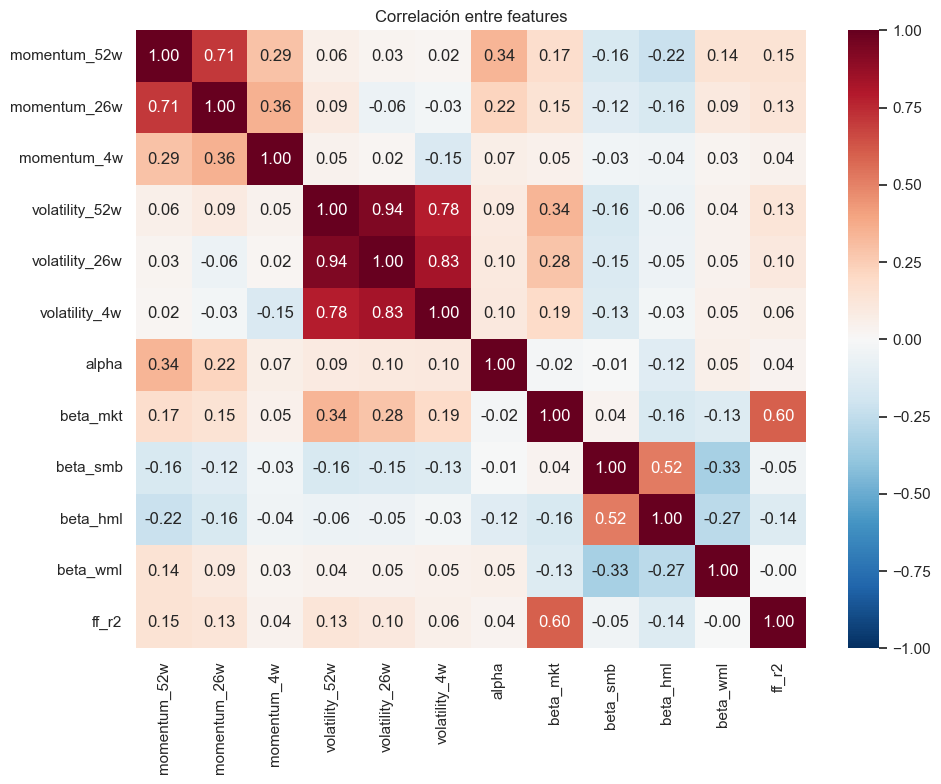

In [30]:
# =============================================================================
# 5.6 – Ensamblaje de la matriz final X, y
# =============================================================================

# Solo semanas donde existen todas las features (desde ventana 52w)
valid_dates = momentum_52w.dropna(how="all").index
# Excluir últimas semanas donde no hay target
valid_dates = valid_dates[valid_dates.isin(target.dropna(how="all").index)]

print(f"Semanas válidas para modelado: {len(valid_dates)}")
print(f"Rango: {valid_dates[0].date()} → {valid_dates[-1].date()}")

# --- Construir dataset largo ---
records = []

for date in valid_dates:
    row_data = {
        "momentum_52w": momentum_52w.loc[date],
        "momentum_26w": momentum_26w.loc[date],
        "momentum_4w":  momentum_4w.loc[date],
        "volatility_52w": volatility_52w.loc[date],
        "volatility_26w": volatility_26w.loc[date],
        "volatility_4w":  volatility_4w.loc[date],
        "target": target.loc[date],
    }
    row_df = pd.DataFrame(row_data)
    row_df.index.name = "isin"
    row_df = row_df.reset_index()
    row_df["date"] = date
    records.append(row_df)

features_long = pd.concat(records, ignore_index=True)

# --- Añadir betas FF como features estáticas ---
ff_cols = ["alpha", "beta_mkt", "beta_smb", "beta_hml", "beta_wml", "r2"]
features_long = features_long.merge(
    ff_betas[ff_cols].reset_index(),
    on="isin",
    how="left"
)

# Renombrar para claridad
features_long = features_long.rename(columns={"r2": "ff_r2"})

# --- Eliminar filas con NaN en features o target ---
feature_columns = [
    "momentum_52w", "momentum_26w", "momentum_4w",
    "volatility_52w", "volatility_26w", "volatility_4w",
    "alpha", "beta_mkt", "beta_smb", "beta_hml", "beta_wml", "ff_r2",
]
all_needed = feature_columns + ["target"]

n_antes = len(features_long)
features_df = features_long.dropna(subset=all_needed).copy()
features_df = features_df.sort_values(["date", "isin"]).reset_index(drop=True)
n_despues = len(features_df)

# --- Definir X e y ---
X = features_df[feature_columns]
y = features_df["target"]

# --- Resumen final ---
print("=" * 70)
print("5.6 – MATRIZ FINAL DE FEATURES Y TARGET")
print("=" * 70)
print(f"Filas antes filtro NaN: {n_antes:,}")
print(f"Filas después: {n_despues:,} ({100*n_despues/n_antes:.1f}%)")
print(f"Fondos únicos: {features_df['isin'].nunique():,}")
print(f"Semanas únicas: {features_df['date'].nunique()}")
print(f"Features ({len(feature_columns)}): {feature_columns}")
print(f"Target (continuo): media={y.mean():.6f}, std={y.std():.6f}, min={y.min():.4f}, max={y.max():.4f}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print("=" * 70)

# Vista previa
display(features_df.head(10))

# Correlación entre features
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlación entre features")
plt.tight_layout()
plt.show()